# Data x hora

In [1]:
# ALg semiautomático

# AProvecha lo construido para operar de forma semiautomática


#1. Buscar resistencias y soportes (se puede actualizar por ej cada una semana)....esas serán las ordenes de compra durante toda la semana
# 2. Conectarse con mt5 y ejecutar y hacer el trallingstop

In [2]:
# Ejecutar con revenAI
# version yf = 0.2.65

# V2: Cambios el 260111...rediseño de macroalgorítmo y continuación de desarrollo

In [3]:
print('Conexion con mt5 en mt5.ipynb [en este mismo proyecto]')
print('Llevado a la práctica en 00_Conexion_mt5.ipynb')

Conexion con mt5 en mt5.ipynb [en este mismo proyecto]
Llevado a la práctica en 00_Conexion_mt5.ipynb


In [4]:
#sys.exit("Entre 'df_oc_all base inicial' y 'df_oc_all base final', hay status que pasan de Abierta a Activa...eso no puede ocurrir [ver id 11]")

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
import itertools
import tqdm
import random
import warnings
import sys
import pickle

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

import mplfinance as mpf
from typing import Union

In [6]:
opcion = 2 # 0 solo actualiza valores y 1 solo ejecuta el algorítmo..2: Realiza ambas cosas

In [7]:
minimo_lotaje = True
continuar_por_ahora = False # Hasta resolver temas de factibilidad como el traspaso de Status Abierta a Activa

In [8]:
conexion_mt5 = False # No hay conexión MT5 por ahora

In [9]:
if opcion == 0:
    actualizar_valores = True
    ejecutar_proceso = False
elif opcion == 1:
    actualizar_valores = False
    ejecutar_proceso = True
elif opcion == 2:
    actualizar_valores = True
    ejecutar_proceso = True

In [10]:
carpeta_data = "../Data/"

In [11]:
import MetaTrader5 as mt5
import pandas as pd


# Inicializar MT5 (Inicialmente, debe conextarse para obtener datos de precio)
mt5.initialize()

# Initialize MT5 connection
if not mt5.initialize():
    print("initialize() failed, error code =", mt5.last_error())
    quit()

In [12]:

valores = ['BTCUSD', 'ETHUSD', 'TSLA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'NFLX']
for valor in valores:
    if not actualizar_valores:
        break
    
    # Nombre del símbolo (depende de tu broker, a veces es BTCUSD, BTCUSD.m, etc.)
    symbol = valor
    print('SY', symbol)

    # Seleccionar símbolo
    mt5.symbol_select(symbol, True)

    # Descargar datos: 100 velas de 1 hora (TIMEFRAME_H1)
    rates = mt5.copy_rates_from_pos(symbol, mt5.TIMEFRAME_H1, 0, 1000) # Max 60000 (en 1000, hay 41 días)

    # Convertir a DataFrame
    df = pd.DataFrame(rates)
    try:
        df['time'] = pd.to_datetime(df['time'], unit='s') # A veces falla
    except Exception as e:
        print(f'Error al convertir tiempo para {valor}: {e}')
        continue
    df.columns = ['DateTime', 'Open', 'High', 'Low', 'Close', 'Tick_Volume', 'Spread', 'Real_Volume'] # Campos selecicionados
    
    display(f'df {len(df)}', df.tail())

    data_old = pd.DataFrame() # Append
    if f'{valor}.csv' in os.listdir(carpeta_data):
        data_old = pd.read_csv(f'{carpeta_data}{valor}.csv')
        data_old['DateTime'] = pd.to_datetime(data_old['DateTime'])
        df['DateTime'] = pd.to_datetime(df['DateTime'])
    data = pd.concat([df, data_old]).drop_duplicates(subset=['DateTime']).reset_index(drop=True) # Los nuevos tienen prioridad, ya que la última hora mostrada en df, está "abierta"...eso hará que, ese bloque horario pase a data_old y después sea pisada por un nuevo df
    data.to_csv(f'{carpeta_data}{valor}.csv', index=False)


SY BTCUSD


'df 1000'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume
995,2026-03-11 06:00:00,69504.20,70007.81,69489.98,69938.25,2887,1260,0
996,2026-03-11 07:00:00,69938.20,70028.09,69491.95,69656.08,3038,1260,0
997,2026-03-11 08:00:00,69656.59,69788.97,69490.67,69649.69,3507,1260,0
998,2026-03-11 09:00:00,69644.69,69760.54,69362.71,69467.63,2979,1260,0
999,2026-03-11 10:00:00,69468.27,69601.26,69383.66,69519.93,1624,1260,0


SY ETHUSD


'df 1000'

...

'df 1000'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume
995,2026-03-10 16:00:00,185.87,185.87,184.99,185.57,3102,11,0
996,2026-03-10 17:00:00,185.56,186.16,185.05,185.67,2951,11,0
997,2026-03-10 18:00:00,185.66,185.76,184.04,184.34,5966,11,0
998,2026-03-10 19:00:00,184.36,184.98,183.64,183.67,3546,11,0
999,2026-03-11 10:00:00,183.87,184.85,183.75,184.82,289,45,0


SY NFLX


'df 1000'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume
995,2026-03-05 16:00:00,98.79,99.55,98.18,99.22,1757,27,0
996,2026-03-05 17:00:00,99.22,99.45,98.33,98.62,1442,27,0
997,2026-03-05 18:00:00,98.61,98.94,98.04,98.20,1443,27,0
998,2026-03-05 19:00:00,98.21,99.03,98.12,99.02,1201,0,0
999,2026-03-05 20:00:00,99.03,99.23,98.50,99.04,712,27,0


# Funciones

In [13]:
if not ejecutar_proceso:
    sys.exit()

In [14]:
def pickle_act(file_name, variable = None, mode = 'open', eliminar_si_problemas = False): #260120
    
    """
    Guarda o carga una variable utilizando la biblioteca pickle.

    Parameters:
        - file_path (str): La ruta al archivo pickle.
        - variable: La variable a guardar (si mode='save') o None (si mode='open').
        - mode (str): 'save' para guardar la variable, 'open' para cargar la variable.

    Returns:
        La variable cargada si mode='open' o None si mode='save'.
    """
    
    dic_mode = {'save': 'wb', 'open': 'rb'}
    #print('file_name', file_name)

    while True:
        try:
            with open(f'{file_name}.pkl', dic_mode[mode]) as file:
                if mode == 'save':
                    pickle.dump(variable, file)
                    return None
                else:
                    #print('file en funciones transversales', f'{file_name}.pkl')
                    if eliminar_si_problemas:
                        try:
                            variable = pickle.load(file)
                        except:
                            os.remove(f'{file_name}.pkl')
                            return pd.DataFrame()
                    else:
                        try:
                            variable = pickle.load(file)
                        except Exception as e:
                            print('Problema en pickle_act 1:', e)
                            try:
                                with open(f'{file_name}.pkl', 'wb') as f:
                                    pickle.dump(df, f)
                            except Exception as e:
                                print('Problema en pickle_act 2:', e)
                                print(f"Intentar ejecutar with open(f'{file_name}.pkl', 'wb') as f: pickle.dump(df, f)")
                                sys.exit('A')
                    return variable
        except Exception as e:
            print(f'Problema en pickle_act 3: {e}')
            sys.exit()
            #time.sleep(10)
    
    return None

In [15]:
# Comentada con typeHints
def calcular_distancias(df: pd.DataFrame, find_low: bool = True, find_high: bool = True) -> pd.DataFrame:
    '''
    Recibe un dattaframe con precios, incluido una columna "t" que va de 0 a 1 (normalizada). Se incluyen además el High y el Low Price en cada fila
    Además, recibe dos booleanos find_low y find_high, que indican si se deben calcular las distancias para Low y High respectivamente. Ambas alternativas son idénticas
    Devuelve el dataframe con las columnas agregadas:
    - Si find_low es True:
        - Low_left: distancia al soporte más cercano a la izquierda (en t) que contenga el Low actual
        - Low_right: distancia al soporte más cercano a la derecha (en t) que contenga el Low actual
    - Si find_high es True:
        - High_left: distancia a la resistencia más cercana a la izquierda (en t) que contenga el High actual
        - High_right: distancia a la resistencia más cercana a la derecha (en t) que contenga el High actual
    Las distancias se miden en unidades de t (tiempo normalizado)
    '''
    n = len(df)
    df = df.copy()
    
    # Activación de campos de outputs (inicialmente como nans)
    if find_low:
        df["Low_left"] = np.nan
        df["Low_right"] = np.nan
    if find_high:
        df["High_left"] = np.nan
        df["High_right"] = np.nan

    max_t = df["t"].max()

    for i in tqdm.tqdm(range(n)): # Para cada registro
        low_val = df.loc[i, "Low"] # Se miden precios Low y High
        high_val = df.loc[i, "High"]
        t_i = df.loc[i, "t"] # Tiempo normalizado actual
        
        if find_low: # Si find_low es True
            # Buscar hacia la izquierda (Low)
            for j in range(i-1, -1, -1): # Se busca el registro a la izquierda (de t hacia atrás) donde low_val esté entre Low y High
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_left"] = t_i - df.loc[j, "t"] # Distancia en t y break (es el punto más cercano)
                    break

            # Buscar hacia la derecha (Low)
            for j in range(i+1, n): # Análogo para la derecha, de t hacia adelante
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_right"] = df.loc[j, "t"] - t_i
                    break

        if find_high: # Análogo para High
            # Buscar hacia la izquierda (High)
            for j in range(i-1, -1, -1):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_left"] = t_i - df.loc[j, "t"]
                    break

            # Buscar hacia la derecha (High)
            for j in range(i+1, n):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_right"] = df.loc[j, "t"] - t_i
                    break

    # Rellenar los NaN con t o max(t) - t (casos en los que se llega al final, a la derecha o a la izquierda sin encontrar un registro que contenga el precio)
    if find_low:
        df["Low_left"] = df["Low_left"].fillna(df["t"])
        df["Low_right"] = df["Low_right"].fillna(max_t - df["t"])
    if find_high:
        df["High_left"] = df["High_left"].fillna(df["t"])
        df["High_right"] = df["High_right"].fillna(max_t - df["t"])

    return df


In [16]:
def obtener_df_extremos(df_0: pd.DataFrame, k: float, n: float, N: int, M: int, OCP: int, conjunto_N = set(), prints_general = False):
    '''
    Recibe el df con los datos de velas (OHLCV) y calcula los soportes óptimos
    # Recibe parámetros para otorgar puntaje a esos soportes óptimos
    '''
    
    # 1. Cálculo de y: Distancia a mínimos anteriores y futuros
    df_extremos = calcular_distancias(df_0) # Calcula las distancias a los mínimos anteriores y futuros
    # Ponderadores (audios wsp personal 251002)
    if 'High_left' in df_extremos.columns: # Depende de si se ocupa find_high, también se pueden considerar las resistencias
        df_extremos['y'] = df_extremos['High_left'] + df_extremos['Low_left'] + k * (df_extremos['High_right'] + df_extremos['Low_right'])
    else:
        df_extremos['y'] = df_extremos['Low_left'] + k * df_extremos['Low_right']
    
    # 2. Cálculo de w: Ponderación por tiempo (se ponderan más los recientes)
    df_extremos['w'] = df_extremos['t'] ** n # t min es 0 y t max es 1 (ya están normalizados, por lo que no hay problema) > t ** n = 0 y t ** n = 1
    
    # BUSQUEDA DE SOPORTES OPTIMOS (Potenciales. En el nuevo lenguaje, sería buscar...)
    # El objetivo es, con M puntos potenciales, llegar a que OCE + OCP = N soportes óptimos [OCE: Ordenes de compra en espera]

    if prints_general:
        print('N-M', N, M)

    p_min, p_max = df_extremos['Low'].min(), df_extremos['Low'].max()
    if prints_general:
        print('p_min y p_max', p_min, p_max)
    
    # Se debe entregar conjunto_N y sizes
    #conjunto_M = set(np.linspace(p_min, p_max, M).tolist()) # M precios equidistantes entre p_min y p_max (potenciales soportes)
    
    # M valores que distribuyen Uniforme entre p_min y p_max
    print('Prueba conjuntoM distribuye Uniforme') # 260119
    conjunto_M = set(np.random.uniform(p_min, p_max, M).tolist())
    ordenes_en_espera = N - OCP # Cantidad de ordenes en espera que deben estar en conjunto_N (N [total] - OCP [ordenes de compra planificadas (ya activadas en la plataforma)])
    L_conjunto_N = len(conjunto_N)
    if L_conjunto_N <= ordenes_en_espera:
        # Rellenar conjunto_N con nuevos soportes aleatorios desde conjunto_M
        delta = ordenes_en_espera - L_conjunto_N
        print('delta', delta, ordenes_en_espera, L_conjunto_N)
        nuevos_soportes = set(random.sample(list(conjunto_M), delta))
        conjunto_N = conjunto_N.union(nuevos_soportes)
    else:
        # Quitar elementos random de conjunto_N para que su tamaño sea ordenes_en_espera
        # No debería entrar aqui
        # En caso de algorítmo semiautomático
        delta = L_conjunto_N - ordenes_en_espera
        # A conjunto N hay que removerle delta elementos aleatorios
        elementos_a_remover = set(random.sample(list(conjunto_N), delta))
        conjunto_N = conjunto_N.difference(elementos_a_remover)
        #sys.exit('Validacion de no entrar 01')
        
    # Remover de conjunto_M los elementos que ya están en conjunto_N
    conjunto_M = conjunto_M.difference(conjunto_N)
    
    # Complementar M si es necesario 260120
    delta_M = M - len(conjunto_M)
    if delta_M > 0:
        nuevos_soportes_M = set(np.random.uniform(p_min, p_max, delta_M).tolist())
        conjunto_M = conjunto_M.union(nuevos_soportes_M)
    
    if (len(conjunto_N) != N) or (len(conjunto_M) != M):
        print('len conjunto_N', len(conjunto_N), 'len conjunto_M', len(conjunto_M))
        print('N y M esperados', N, M)
        sys.exit('Error en tamaños de conjunto_N y conjunto_M en obtener_df_extremos')
    # Hasta aqui bloque agregado el 260120
    
    if prints_general:
        print('L(N) * L(M)', len(conjunto_N), len(conjunto_M), len(conjunto_N) * (len(conjunto_M)))

    return df_extremos, conjunto_N, conjunto_M



In [17]:
def graficar_df_extremos(df_extremos, graficar = False):
    
    if not graficar:
        return None
    # Grafica en una matriz de 2x1, Low e y
    """
    plt.figure(figsize=(21, 10))
    #plt.subplot(1, 1, 1)
    plt.plot(df_extremos['DateTime'], df_extremos['Low'], linestyle='-', color='b', label='Low')
    plt.plot(df_extremos['DateTime'], df_extremos['High'], linestyle='-', color='g', label='High')
    plt.xlabel('DateTime')
    plt.ylabel('Low')
    plt.title('Gráfico de Low en función de DateTime')
    plt.grid()
    plt.legend()
    plt.show()
    """
    print('TO DO: Poner los parámetros asociados en cada curva, ej y = izq + lambda * der....w = t ** n...')
    plt.figure(figsize=(21, 10))
    plt.subplot(2, 2, 1)
    plt.plot(df_extremos['DateTime'], df_extremos['y'], linestyle='-', color='r')
    plt.xlabel('DateTime')
    plt.ylabel('Peso')
    plt.title('y (a mayor y, mayor distancia izq y derecha con otras velas)')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.subplot(2, 2, 2)
    plt.plot(df_extremos['DateTime'], df_extremos['w'], linestyle='-', color='m')
    plt.xlabel('DateTime')
    plt.ylabel('Peso')
    plt.title('w (a mayor w, más reciente es la vela)')
    plt.grid()
    plt.legend()
    plt.subplot(2, 2, 3)
    plt.plot(df_extremos['DateTime'], df_extremos['h_dist'], linestyle='-', color='c')
    plt.xlabel('DateTime')
    plt.ylabel('Peso')
    plt.title('h_dist (mayor h_dist implica más cercanía con el soporte seleccionado más cercano)')
    plt.grid()
    plt.subplot(2, 2, 4)
    plt.plot(df_extremos['DateTime'], df_extremos['z'], linestyle='-', color='black')
    plt.xlabel('DateTime')
    plt.ylabel('Peso')
    plt.title('z (w * h_dist * y)')
    plt.grid()
    plt.legend()
    plt.show()

    return None

In [18]:
# Al Low en df extremos, asignarle el soporte más cercano en conjunto_N
# Revisadas en nueva versión
def asignar_soporte(df, soportes):
    # Devuelve la distancia entre el Low y el soporte más cercano
    df = df.copy()
    df['soporte'] = df['Low'].apply(lambda x: min(soportes, key=lambda s: abs(s - x))) # Entrega s en soportes
    return df

def calcular_FO(df_extremos, conjunto_N, lambda_ponderador):

    biobjetivo = True
    
    df_extremos = asignar_soporte(df_extremos, conjunto_N) # Se asigna el soporte más cercano
    df_extremos['dist'] = (df_extremos['soporte'] - df_extremos['Low']) ** 2 # Se Penalizan distancias miuy grandes (corrección 260111: ANtes era dist_soporte - Low, pero en la función ya calcula la distancia)
    dist_max = df_extremos['dist'].max()
    df_extremos['h_dist'] = 1 - df_extremos['dist'] / dist_max # Normaliza, buscando que las distancias más pequeñas tengan mayor H_dist
    df_extremos
    
    # Calcular la función objetivo

    df_extremos['z'] = df_extremos['y'] * df_extremos['w'] * df_extremos['h_dist'] # Multiplicación de los tres términos
    # z debe ser grande
    # y: mejor representación de soporte (más aislado)
    # w: mas cercano (premia a las velas más recientes)
    # h_dist: mejor ajuste al soporte del conjunto n (más cercano al n asignado)

    L_n = list(conjunto_N)
    L_n.sort()
    H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))] # Distancias entre los soportes del conjunto_N

    # calcula promedio de conjunto H_n
    promedio_conjunto_H = np.mean(H_n)
    # desviación estándar de conjunto H_n
    desviacion_conjunto_H = np.std(H_n)

    # cv del conjunto H_n
    cv_conjunto_H = desviacion_conjunto_H / promedio_conjunto_H

    # cv_conjunto_N debe ser pequeño
    
    if biobjetivo:
        #print("df_extremos['z'].sum() / len(df_extremos)", df_extremos['z'].sum() / len(df_extremos), df_extremos['z'].sum(), len(df_extremos))
        #print('cv_conjunto_H', cv_conjunto_H, desviacion_conjunto_H, promedio_conjunto_H)
        # FO = sum(z) - lambda * cv_conjunto_N
        #sys.exit('También normalizar cv conjunto H y definir un nuevo lambda_ponderador inicial')
        FO = df_extremos['z'].sum() / len(df_extremos) - lambda_ponderador * cv_conjunto_H # Se divide por len para normalizar
    else:
        FO = (df_extremos['z'].sum() / len(df_extremos)) / cv_conjunto_H
    
    #if j % 400 == 0:
    #    print('F', j, df_extremos['z'].sum() / len(df_extremos) / cv_conjunto_H, df_extremos['z'].sum() / len(df_extremos), cv_conjunto_H)
    FO = float(FO)
    # 260119
    particion = [df_extremos['z'].sum() / len(df_extremos), cv_conjunto_H]
    return FO, df_extremos, particion

In [19]:
"""
def traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes):
    if sizes == []:
        return conjunto_M, conjunto_N
    if sizes[0] + sizes[1] != len(conjunto_M) + len(conjunto_N):
        sys.exit('Error en sizes declarados')
    elif (sizes[0] != len(conjunto_M)) or (sizes[1] != len(conjunto_N)):
        delta = len(conjunto_M) - sizes[0]
        if delta > 0:
            #pasar delta elementos random de conjunto_M a conjunto_N
            elementos_a_pasar = random.sample(list(conjunto_M), delta)
            for elem in elementos_a_pasar:
                conjunto_M.remove(elem)
                conjunto_N.add(elem)
        else:
            #pasar delta elementos random de conjunto_N a conjunto_M
            elementos_a_pasar = random.sample(list(conjunto_N), -delta)
            for elem in elementos_a_pasar:
                conjunto_N.remove(elem)
                conjunto_M.add(elem)
    return conjunto_M, conjunto_N
"""

"\ndef traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes):\n    if sizes == []:\n        return conjunto_M, conjunto_N\n    if sizes[0] + sizes[1] != len(conjunto_M) + len(conjunto_N):\n        sys.exit('Error en sizes declarados')\n    elif (sizes[0] != len(conjunto_M)) or (sizes[1] != len(conjunto_N)):\n        delta = len(conjunto_M) - sizes[0]\n        if delta > 0:\n            #pasar delta elementos random de conjunto_M a conjunto_N\n            elementos_a_pasar = random.sample(list(conjunto_M), delta)\n            for elem in elementos_a_pasar:\n                conjunto_M.remove(elem)\n                conjunto_N.add(elem)\n        else:\n            #pasar delta elementos random de conjunto_N a conjunto_M\n            elementos_a_pasar = random.sample(list(conjunto_N), -delta)\n            for elem in elementos_a_pasar:\n                conjunto_N.remove(elem)\n                conjunto_M.add(elem)\n    return conjunto_M, conjunto_N\n"

In [20]:
def buscar_soportes_optimos(valor, N, df_extremos, conjunto_N, conjunto_M, lambda_ponderador, sizes = [], prints_general= False, n_randoms_iniciales = 0):
    
    #conjunto_M, conjunto_N = traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes)
    len_N_original = len(conjunto_N)
    
    # Uno a uno, reemplaza un punto del conjunto N por uno del conjunto M
    if prints_general:
        print('Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %')    
    df_FO = pd.DataFrame(columns = ['Iteracion', 'FO']) # Guarda los registros del valor de FO en cada iteración

    #sys.exit('[MODIFICAR] Conjunto N tambien debe incluir los soportes ACTIVOS. Con los soportes potenciales, hay que completar los ABIERTOS, pero los ACTIVOS deben permanecer en el conjunto N')
    FO = -float('inf')
    if n_randoms_iniciales > 0:
        for j in tqdm.tqdm(range(n_randoms_iniciales), desc='Random iniciales'):
            # Generar conjuntos N y M aleatorios
            conjunto_N_iter = set(random.sample(list(conjunto_N.union(conjunto_M)), len_N_original))
            conjunto_M_iter = conjunto_N.union(conjunto_M).difference(conjunto_N_iter)
            
            FO_iter, df_extremos_iter, particion_FO_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador) # Se evalúa la función objetivo
            
            if FO_iter > FO: # Si es mejor, se actualiza
                FO = FO_iter
                df_extremos = df_extremos_iter
                particion_FO = particion_FO_iter
                conjunto_N = conjunto_N_iter
                conjunto_M = conjunto_M_iter
                
    # inicialización
    FO, df_extremos, particion_FO = calcular_FO(df_extremos, conjunto_N, lambda_ponderador) # Función objetivo con conjuntos iniciales
    i = 0
    df_registros = pd.DataFrame()
    while True:
        cambios = False
        #print('i', i)
        j = 0
        #df_n = pd.DataFrame('n': list(conjunto_N))
        #df_m = pd.DataFrame('m': list(conjunto_M))
        #df_iters = pd.DataFrame(itertools.product(df_n['n'], df_m['m']), columns=['n', 'm'])
        for n, m in tqdm.tqdm(itertools.product(conjunto_N, conjunto_M), total=len(conjunto_N)*len(conjunto_M)): # Para cada par (n,m) de los conjuntos N y M
            j += 1
            #print(n, m)
            
            # Se cambia el par n por m, de los conjuntos
            conjunto_N_iter = conjunto_N.copy()
            conjunto_N_iter.remove(n)
            conjunto_N_iter.add(m)
            
            conjunto_M_iter = conjunto_M.copy()
            conjunto_M_iter.remove(m)
            conjunto_M_iter.add(n)
            
            if len(conjunto_N_iter) != len_N_original:
                print(len(conjunto_N), len(conjunto_N_iter))
                
                sys.exit('Error en tamaño conjunto N iterado')
            FO_iter, df_extremos_iter, particion_FO_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador) # Se evalúa la función objetivo
            
            if FO_iter > FO: # Si es mejor, break y se vuelven a recorrer todos los pares
                #print(f'Nueva FO: {round(FO_iter, 1)} > {round(FO, 1)}, con n={round(n, 0)} por m={round(m, 0)}')
                #print(f'Mejora de {round(FO_iter - FO, 2)}')
                FO = FO_iter
                df_extremos = df_extremos_iter
                particion_FO = particion_FO_iter
                conjunto_N = conjunto_N_iter
                conjunto_M = conjunto_M_iter
                cambios = True
                pickle_act((f'conjuntosN/{valor}_{N}_beta'), conjunto_N, 'save')
                pickle_act((f'conjuntosN/respaldos/{valor}_{N}_beta'), conjunto_N, 'save')
                break
        
              
        df_FO_new = pd.DataFrame({'Iteracion': [i], 'FO': [FO], 'FO1': [particion_FO[0]], 'FO2': [particion_FO[1]], 'ratio': [particion_FO[0] / particion_FO[1]], 'n_iters': [j], 'prop_total': [j / (len(conjunto_N) * len(conjunto_M))]}) # Se guarda el registro
        
        if i % 10 == 0:
            display('df_FO_new', df_FO_new)
        df_FO = pd.concat([df_FO, df_FO_new])
        i += 1
        if not cambios:
            break
    
    return conjunto_N, conjunto_M, df_extremos, df_FO


In [21]:
def buscar_soportes_optimos_v2(df_extremos, conjunto_N, conjunto_M, lambda_ponderador, sizes = [], prints_general= False): #260120
    # v2 itera todas las combinaciones hasta el final y eleige la mejor
    #conjunto_M, conjunto_N = traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes)
    len_N_original = len(conjunto_N)
    
    # Uno a uno, reemplaza un punto del conjunto N por uno del conjunto M
    if prints_general:
        print('Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %')    
    df_FO = pd.DataFrame(columns = ['Iteracion', 'FO']) # Guarda los registros del valor de FO en cada iteración

    #sys.exit('[MODIFICAR] Conjunto N tambien debe incluir los soportes ACTIVOS. Con los soportes potenciales, hay que completar los ABIERTOS, pero los ACTIVOS deben permanecer en el conjunto N')

    # inicialización
    FO, df_extremos, particion_FO = calcular_FO(df_extremos, conjunto_N, lambda_ponderador) # FUnción objetivo con conjuntos iniciales
    print('FO inicial', FO)
    i = 0
    while True:
        #cambios = False
        #print('i', i)
        j = 0
        FO_j = -float('inf')
        for n, m in tqdm.tqdm(itertools.product(conjunto_N, conjunto_M), total=len(conjunto_N)*len(conjunto_M)): # Para cada par (n,m) de los conjuntos N y M
            j += 1
            #print(n, m)
            
            # Se cambia el par n por m, de los conjuntos
            conjunto_N_iter = conjunto_N.copy()
            conjunto_N_iter.remove(n)
            conjunto_N_iter.add(m)
            
            conjunto_M_iter = conjunto_M.copy()
            conjunto_M_iter.remove(m)
            conjunto_M_iter.add(n)
            
            if len(conjunto_N_iter) != len_N_original:
                print(len(conjunto_N), len(conjunto_N_iter))
                
                sys.exit('Error en tamaño conjunto N iterado')
            FO_iter, df_extremos_iter, particion_FO_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador) # Se evalúa la función objetivo
            
            if FO_iter > FO_j: # Si es mejor, break y se vuelven a recorrer todos los pares
                #print(f'Nueva FO: {round(FO_iter, 1)} > {round(FO, 1)}, con n={round(n, 0)} por m={round(m, 0)}')
                #print(f'Mejora de {round(FO_iter - FO, 2)}')
                FO_j = FO_iter
                mejor_tupla = (n, m)
        
        # Si es mejor que FO, se hace el mejor de todos los cambios
        if FO_j > FO:
            n, m = mejor_tupla
            # Se cambia el par n por m, de los conjuntos
            conjunto_N.remove(n)
            conjunto_N.add(m)
            conjunto_M.remove(m)
            conjunto_M.add(n)
            FO = FO_j
        else:
            break # Se encuentra mejor resultado
        
        df_FO_new = pd.DataFrame({'Iteracion': [i], 'FO': [FO], 'FO1': [particion_FO[0]], 'FO2': [particion_FO[1]], 'ratio': [particion_FO[0] / particion_FO[1]], 'n_iters': [j], 'prop_total': [j / (len(conjunto_N) * len(conjunto_M))]}) # Se guarda el registro
        
        #if i % 10 == 0:
        display('df_FO_new', df_FO_new)
        df_FO = pd.concat([df_FO, df_FO_new])
        i += 1
        #if not cambios:
        #    break
    
    return conjunto_N, conjunto_M, df_extremos, df_FO


In [22]:
def buscar_soportes_optimos_v3(df_extremos, conjunto_N, conjunto_M, lambda_ponderador, sizes = [], prints_general= False, n_randoms_iniciales = 0):
    
    #conjunto_M, conjunto_N = traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes)
    len_N_original = len(conjunto_N)
    
    # Uno a uno, reemplaza un punto del conjunto N por uno del conjunto M
    if prints_general:
        print('Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %')    
    df_FO = pd.DataFrame(columns = ['Iteracion', 'FO']) # Guarda los registros del valor de FO en cada iteración

    #sys.exit('[MODIFICAR] Conjunto N tambien debe incluir los soportes ACTIVOS. Con los soportes potenciales, hay que completar los ABIERTOS, pero los ACTIVOS deben permanecer en el conjunto N')
    FO = -float('inf')
    if n_randoms_iniciales > 0:
        for j in tqdm.tqdm(range(n_randoms_iniciales), desc='Random iniciales'):
            # Generar conjuntos N y M aleatorios
            conjunto_N_iter = set(random.sample(list(conjunto_N.union(conjunto_M)), len_N_original))
            conjunto_M_iter = conjunto_N.union(conjunto_M).difference(conjunto_N_iter)
            
            FO_iter, df_extremos_iter, particion_FO_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador) # Se evalúa la función objetivo
            
            if FO_iter > FO: # Si es mejor, se actualiza
                FO = FO_iter
                df_extremos = df_extremos_iter
                particion_FO = particion_FO_iter
                conjunto_N = conjunto_N_iter
                conjunto_M = conjunto_M_iter
                
    # inicialización
    FO, df_extremos, particion_FO = calcular_FO(df_extremos, conjunto_N, lambda_ponderador) # Función objetivo con conjuntos iniciales
    print('FO inicial', FO)
    i = 0
    df_registros = pd.DataFrame(columns = ['n', 'm', 'delta'])
    while True:
        cambios = False
        #print('i', i)
        #j = 0
        df_n = pd.DataFrame({'n': list(conjunto_N)})
        df_m = pd.DataFrame({'m': list(conjunto_M)})
        df_iters = df_n.merge(df_m, how='cross')
        df_iters = df_iters.merge(df_registros, on=['n', 'm'], how='left')
        df_iters['delta'] = df_iters['delta'].fillna(0)
        df_iters = df_iters.sort_values(by='delta', ascending=False).reset_index(drop=True) # Descendiente, para buscar un cambio positivo lo antes posible
        for j in range(len(df_iters)):
            n = df_iters.loc[j, 'n']
            m = df_iters.loc[j, 'm']
        #for n, m in tqdm.tqdm(itertools.product(conjunto_N, conjunto_M), total=len(conjunto_N)*len(conjunto_M)): # Para cada par (n,m) de los conjuntos N y M
            #j += 1
            #print(n, m)
            
            # Se cambia el par n por m, de los conjuntos
            conjunto_N_iter = conjunto_N.copy()
            conjunto_N_iter.remove(n)
            conjunto_N_iter.add(m)
            
            conjunto_M_iter = conjunto_M.copy()
            conjunto_M_iter.remove(m)
            conjunto_M_iter.add(n)
            
            if len(conjunto_N_iter) != len_N_original:
                print(len(conjunto_N), len(conjunto_N_iter))
                
                sys.exit('Error en tamaño conjunto N iterado')
            FO_iter, df_extremos_iter, particion_FO_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador) # Se evalúa la función objetivo
            
            delta = FO_iter - FO
            # busca (n, m) en df_registros y reeplaza delta si existe la tupla, si no, creala
            if ((df_registros['n'] == n) & (df_registros['m'] == m)).any():
                df_registros.loc[(df_registros['n'] == n) & (df_registros['m'] == m), 'delta'] = delta
            else:
                df_registros = pd.concat([df_registros, pd.DataFrame({'n': [n], 'm': [m], 'delta': [delta]})])
                
            # Se evalúa si es mejor
            if FO_iter > FO: # Si es mejor, break y se vuelven a recorrer todos los pares
                #print(f'Nueva FO: {round(FO_iter, 1)} > {round(FO, 1)}, con n={round(n, 0)} por m={round(m, 0)}')
                #print(f'Mejora de {round(FO_iter - FO, 2)}')
                FO = FO_iter
                df_extremos = df_extremos_iter
                particion_FO = particion_FO_iter
                conjunto_N = conjunto_N_iter
                conjunto_M = conjunto_M_iter
                cambios = True
                break
        
              
        df_FO_new = pd.DataFrame({'Iteracion': [i], 'FO': [FO], 'FO1': [particion_FO[0]], 'FO2': [particion_FO[1]], 'ratio': [particion_FO[0] / particion_FO[1]], 'n_iters': [j], 'prop_total': [j / (len(conjunto_N) * len(conjunto_M))]}) # Se guarda el registro
        
        if i % 1 == 0:
            display('df_FO_new', df_FO_new)
        df_FO = pd.concat([df_FO, df_FO_new])
        i += 1
        if not cambios:
            break
    
    return conjunto_N, conjunto_M, df_extremos, df_FO


In [23]:
def buscar_soportes_optimos_v4(valor, N, df_extremos, conjunto_N, conjunto_M, lambda_ponderador, sizes = [], prints_general= False, n_randoms_iniciales = 0):
    
    #conjunto_M, conjunto_N = traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes)
    len_N_original = len(conjunto_N)
    
    # Uno a uno, reemplaza un punto del conjunto N por uno del conjunto M
    if prints_general:
        print('Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %')    
    df_FO = pd.DataFrame(columns = ['Iteracion', 'FO']) # Guarda los registros del valor de FO en cada iteración

    #sys.exit('[MODIFICAR] Conjunto N tambien debe incluir los soportes ACTIVOS. Con los soportes potenciales, hay que completar los ABIERTOS, pero los ACTIVOS deben permanecer en el conjunto N')
    FO = -float('inf')
    if n_randoms_iniciales > 0:
        for j in tqdm.tqdm(range(n_randoms_iniciales), desc='Random iniciales'):
            # Generar conjuntos N y M aleatorios
            conjunto_N_iter = set(random.sample(list(conjunto_N.union(conjunto_M)), len_N_original))
            conjunto_M_iter = conjunto_N.union(conjunto_M).difference(conjunto_N_iter)
            
            FO_iter, df_extremos_iter, particion_FO_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador) # Se evalúa la función objetivo
            
            if FO_iter > FO: # Si es mejor, se actualiza
                FO = FO_iter
                df_extremos = df_extremos_iter
                particion_FO = particion_FO_iter
                conjunto_N = conjunto_N_iter
                conjunto_M = conjunto_M_iter
                
    # inicialización
    FO, df_extremos, particion_FO = calcular_FO(df_extremos, conjunto_N, lambda_ponderador) # Función objetivo con conjuntos iniciales
    print('FO inicial', FO)
    i = 0
    df_registros = pd.DataFrame()
    while True:
        cambios = False
        #print('i', i)
        j = 0
        lista_N, lista_M = list(conjunto_N), list(conjunto_M)
        #df_n = pd.DataFrame('n': list(conjunto_N))
        #df_m = pd.DataFrame('m': list(conjunto_M))
        #df_iters = pd.DataFrame(itertools.product(df_n['n'], df_m['m']), columns=['n', 'm'])
        for m, n in tqdm.tqdm(itertools.product(lista_M, lista_N), total=len(lista_M)*len(lista_N)): # Para cada par (n,m) de los conjuntos N y M
            j += 1
            #print(n, m)
            
            # Se cambia el par n por m, de los conjuntos
            lista_N_iter = lista_N[:] # Copia
            lista_N_iter.remove(n)
            lista_N_iter.append(m)
            
            lista_M_iter = lista_M[:] # Copia
            lista_M_iter.remove(m)
            lista_M_iter.append(n)
            
            conjunto_N_iter = set(lista_N_iter)
            conjunto_M_iter = set(lista_M_iter)
            
            if len(lista_N_iter) != len_N_original:
                print(len(conjunto_N), len(conjunto_N_iter))
                
                sys.exit('Error en tamaño conjunto N iterado')
            FO_iter, df_extremos_iter, particion_FO_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador) # Se evalúa la función objetivo
            
            if FO_iter > FO: # Si es mejor, break y se vuelven a recorrer todos los pares
                #print(f'Nueva FO: {round(FO_iter, 1)} > {round(FO, 1)}, con n={round(n, 0)} por m={round(m, 0)}')
                #print(f'Mejora de {round(FO_iter - FO, 2)}')
                FO = FO_iter
                df_extremos = df_extremos_iter
                particion_FO = particion_FO_iter
                
                # NUevo ordenamiento de listas
                # Para lista N, si la lista es [A | n(m) | B], donde A es todo lo que viene antes de n (reemplazado por m) y B despues, quiero dejar el orden [B | A | n(m)]
                pos_n = lista_N.index(n)
                lista_N = lista_N[pos_n + 1:] + lista_N[:pos_n] + [m]
                pos_m = lista_M.index(m)
                lista_M = lista_M[pos_m + 1:] + lista_M[:pos_m] + [n]
                
                #lista_N = lista_N_iter[:]
                #lista_M = lista_M_iter[:]
                # reordenar listas
                
                cambios = True
                conjunto_N = set(lista_N)
                conjunto_M = set(lista_M)
                pickle_act((f'conjuntosN/{valor}_{N}_beta'), conjunto_N, 'save')
                break
        
              
        df_FO_new = pd.DataFrame({'Iteracion': [i], 'FO': [FO], 'FO1': [particion_FO[0]], 'FO2': [particion_FO[1]], 'ratio': [particion_FO[0] / particion_FO[1]], 'n_iters': [j], 'prop_total': [j / (len(conjunto_N) * len(conjunto_M))]}) # Se guarda el registro
        
        if i % 1 == 0:
            display('df_FO_new', df_FO_new)
        df_FO = pd.concat([df_FO, df_FO_new])
        i += 1
        if not cambios:
            break
    
    return conjunto_N, conjunto_M, df_extremos, df_FO


In [24]:
def graficar_performance_FO(df_FO, graficar = False):
    if not graficar:
        return None
    # Graficar df_FO a doble eje (FO y n_iters vs iteracion)
    #display(f'df_FO {len(df_FO)}', df_FO)
    if len(df_FO) <= 1:
        print('FO sin Evolución \n\n\n')
        return None
    plt.figure(figsize = (21, 7))
    plt.plot(df_FO['Iteracion'], df_FO['FO'], linestyle='-', color='b', label='FO')
    plt.ylabel('FO')
    plt.xlabel('Iteración')
    plt.twinx()
    plt.plot(df_FO['Iteracion'], df_FO['n_iters'], linestyle='-', color='r', label='n_iters')
    plt.ylabel('n_iters')
    plt.title('Evolución de la Función Objetivo (FO) y n_iters por Iteración')
    plt.legend()
    plt.grid()
    plt.show()
    
    print('Gráfico Biobjetivo') # 260119
    plt.figure(figsize = (21, 7))
    plt.plot(df_FO['Iteracion'], df_FO['FO1'], linestyle='-', color='b', label='FO1')
    plt.ylabel('FO1')
    plt.xlabel('Iteración')
    plt.twinx()
    plt.plot(df_FO['Iteracion'], df_FO['FO2'], linestyle='-', color='r', label='FO2')
    plt.ylabel('FO2')
    plt.title('Evolución de la Función Objetivo (FO) y n_iters por Iteración')
    plt.legend()
    plt.grid()
    plt.show()
    return None

In [25]:
def graficar_soportes_all(df_0, conjunto_N, graficar = False, graficar_zoom = False):
        
    if graficar_zoom:
        df_0 = df_0.tail(100)
        minimo, maximo = df_0['Low'].min(), df_0['High'].max()
        plt.figure(figsize = (21, 7))
        plt.plot(df_0['DateTime'], df_0['Low'], linestyle='-', color='b', label='Low')
        plt.plot(df_0['DateTime'], df_0['High'], linestyle='-', color='g', label='High')
        for n in list(conjunto_N):
            if minimo <= n <= maximo:
                plt.axhline(y = n, color = 'r', linestyle = '--', alpha = 0.5)
        plt.xlabel('DateTime')
        plt.ylabel('Price')
        plt.title('Gráfico de Low en función de DateTime [Zoom]')
        plt.grid() # Agrega una cuadrícula
        plt.legend()
        plt.show()
        return None
    
    if not graficar:
        return None
        

    plt.figure(figsize = (21, 7))
    plt.plot(df_0['DateTime'], df_0['Low'], linestyle='-', color='b', label='Low')
    plt.plot(df_0['DateTime'], df_0['High'], linestyle='-', color='g', label='High')
    for n in list(conjunto_N):
        plt.axhline(y = n, color = 'r', linestyle = '--', alpha = 0.5)
    plt.xlabel('DateTime')
    plt.ylabel('Price')
    plt.title('Gráfico de Low en función de DateTime')
    plt.grid() # Agrega una cuadrícula
    plt.legend()
    plt.show()
    
    return None


In [26]:
def generar_nuevas_oc(df_oc_all, conjunto_N, limite_low, limite_high, beta_low, beta_up, ultimo_cierre, delta_cambio_SL, delta_trigger, ultimo_periodo, delta_SL_LP):
    df_oc = pd.DataFrame()
    id_ = df_oc_all.shape[0] + 1
    n_distinct = set() # Por defecto vacío
    
    display('df_oc_all base inicial', df_oc_all.head(15))
    ids_abiertos = []
    if len(df_oc_all) > 0:
        ids_abiertos = df_oc_all[df_oc_all['Status'] == 'Abierta']['id'].tolist()
        #dfa1 = df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True)
        #display('A1', df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True))

    if ('Status' in df_oc_all.columns) and ('Monto Compra (lotes)' in df_oc_all.columns):
        df_rev = df_oc_all[(df_oc_all['Status'] == 'Activa') & (df_oc_all['Monto Compra (lotes)'].notna())]
        if len(df_rev) > 0:
            display('df_rev', df_rev)
            sys.exit('No pueden haber activas con monto de compra notna')
    
    
    if len(df_oc_all) > 0:
        ##display('A2', df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True))
        #dfa2 = df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True)
        # Si están activas, se desactivan
        df_oc_all['Status'] = np.where(df_oc_all['Status'] == 'Activa', 'Recien Inactiva', df_oc_all['Status'])
        n_distinct = set(df_oc_all[df_oc_all['Status'] == 'Recien Inactiva']['n'])
        #dfa3 = df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True)
        #display('A3', df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True))
    #display('df_oc_all base inicial 1', df_oc_all)
    
    #print('conjunto_N', conjunto_N)
    #display('df_oc_all en generar_nuevas_oc', df_oc_all)
        
    for n in list(conjunto_N):
        if n in n_distinct: # No se "reemplaza" un soporte que se mantiene
            # Volver a "Activar" solo si status no es "Abierta"
            df_oc_all['Status'] = np.where((df_oc_all['n'] == n) & (df_oc_all['Status'] != 'Abierta'), 'Activa', df_oc_all['Status'])
            # Si existe
            if len(df_oc_all[(df_oc_all['n'] == n) & (df_oc_all['Status'] == 'Activa')]) > 0:
                continue # No agregar nuevamente
        #print(n)
        if n < limite_low:
            beta = beta_low
        if n > limite_high:
            beta = beta_up
        else: # interpolación
            beta = beta_low + (beta_up - beta_low) * (n - limite_low) / (limite_high - limite_low)
        
        # Definir si es superior o inferior
        if n <= ultimo_cierre:
            tipo_oc = 'I'  # Inferior
            cambio_SL = None
            trigger = n # Se ejecuta la orden de compra en n
        else:
            tipo_oc = 'S'  # Superior
            cambio_SL = n * (1 + delta_cambio_SL / 100)
            trigger = cambio_SL * (1 + delta_trigger / 100)
        
        
        df_oc_new = pd.DataFrame({'id': [id_],
                                'tipo_oc': [tipo_oc],
                                'n': [n],
                                'beta': [beta], # Proporcion de la cuenta a comprar
                                'cambio_SL': [cambio_SL],
                                'trigger': [trigger],
                                'SL_LP': [n - delta_SL_LP],
                                'Status': ['Activa'],
                                'Monto Compra (lotes)': [np.nan],
                                'Valor_actual': [0]}) # Activa (esperando gatillar), Inactiva (fue reemplazada), Abierta (actualmente abierta), 'Cerrada' (se cerró la orden)
        df_oc = pd.concat([df_oc, df_oc_new])
        id_ += 1
        #print('beta para n =', n, ' es ', beta)

    #if len(df_oc_all) > 0:
        #dfa4 = df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True)
    #    display('A4', df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True))

    if len(df_oc) > 0:
        df_oc['ultimo_cierre'] = ultimo_cierre
        df_oc['periodo'] = ultimo_periodo
        
        #display(f'df_oc {len(conjunto_N)}', df_oc)
        df_oc = df_oc[['periodo', 'ultimo_cierre', 'id', 'tipo_oc', 'n', 'beta', 'cambio_SL', 'trigger', 'SL_LP', 'Status', 'Monto Compra (lotes)', 'Valor_actual']]
        df_oc_all = pd.concat([df_oc_all, df_oc]).reset_index(drop=True)
    df_oc_all['Status'] = np.where(df_oc_all['Status'] == 'Recien Inactiva', 'Inactiva', df_oc_all['Status'])
    #if len(df_oc_all) > 0:
        #dfa5 = df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True)
        #display('A5', df_oc_all[df_oc_all['Status'] == 'Abierta'].reset_index(drop = True))

    ids_activos = []
    if len(df_oc_all) > 0:
        ids_activos = df_oc_all[df_oc_all['Status'] == 'Activa']['id'].tolist()
        
    # Valida si algun id pasa de Abierto a Activo
    if any(id_ in ids_abiertos for id_ in ids_activos):
        # print esos ids
        print("Los siguientes ids pasaron de Abierta a Activa:", [id_ for id_ in ids_activos if id_ in ids_abiertos])
        #display('dfa1', dfa1)
        #display('dfa2', dfa2)
        #display('dfa3', dfa3)
        #display('dfa4', dfa4)
        #display('dfa5', dfa5)
        #dfa1.to_csv('dfa1.csv', index=False, sep = ';', decimal = ',')
        #dfa2.to_csv('dfa2.csv', index=False, sep = ';', decimal = ',')
        #dfa3.to_csv('dfa3.csv', index=False, sep = ';', decimal = ',')
        #dfa4.to_csv('dfa4.csv', index=False, sep = ';', decimal = ',')
        #dfa5.to_csv('dfa5.csv', index=False, sep = ';', decimal = ',')
        sys.exit("Entre 'df_oc_all base inicial' y 'df_oc_all base final', hay status que pasan de Abierta a Activa...eso no puede ocurrir")
    
    display('df_oc_all base final', df_oc_all.head(15))
    return df_oc_all

In [27]:
def actualizar_stop_loss_ordenes_abiertas(df_oc_all, cambio_SL, valor, continuar_por_ahora):
    
    if continuar_por_ahora:
        return df_oc_all
    
    print('\n\n\n actualizar_stop_loss_ordenes_abiertas')
    display('df_oc_all', df_oc_all)
    print('cambio_SL', cambio_SL)
    sys.exit('Desarrollar, solo para operaciones abiertas y si cambio_SL es mayor al precio de compra')

In [28]:
# Prueba
trigger = 1202.557551
cuenta_size = 3000
beta = 4.99169561
monto_compra = 0.1
grano_lote = 0.1
U = 1

trigger - cuenta_size * (beta / 100) / (monto_compra * U)
sl_lp_new = 0
(cuenta_size * (beta / 100) / ((trigger - sl_lp_new) * U)) // grano_lote * grano_lote

0.1

In [29]:
# Prueba
monto_compra = (cuenta_size * (beta / 100) / ((trigger - sl_lp_new) * U)) // grano_lote * grano_lote
sl_lp_new = trigger - cuenta_size * (beta / 100) / (monto_compra * U)
sl_lp_new

-294.9511319999999

In [30]:
def ejecutar_orden_de_compra(df_oc_all, cuenta_size, beta, trigger, sl_lp, valor, _id, minimo_lotaje = False):
    if valor not in ['BTCUSD', 'ETHUSD']:
        sys.exit('Solo desarrollado para BTCUSD por ahora...cambiar lógica de grano lote y U')
        
    granos_lotes = {'BTCUSD': 0.01, 'ETHUSD': 0.1}
    unidades = {'BTCUSD': 1, 'ETHUSD': 1}
    grano_lote = granos_lotes[valor] # tamaño mínimo de lote para BTCUSD
    U = unidades[valor] # Unidades de lote: 1 lote = 1 BTCUSD

    monto_compra = (cuenta_size * (beta / 100) / ((trigger - sl_lp) * U)) // grano_lote * grano_lote
    monto_compra # Lotes
    e1, e2, e3, e4 = False, False, False, False
    # Entonces, se ajusta  el SL_LP 
    if minimo_lotaje:
        monto_compra = grano_lote
        sl_lp_new = trigger - cuenta_size * (beta / 100) / (monto_compra * U)
        e1 = True

    elif monto_compra == 0:
        sl_lp_new = sl_lp
        e2 = True
    else:
        sl_lp_new = trigger - cuenta_size * (beta / 100) / (monto_compra * U)
        e3 = True
    # Aunque sean operaciones de mínimo lotaje
    if sl_lp_new < 0:
        sl_lp_new = 0
        monto_compra = (cuenta_size * (beta / 100) / ((trigger - sl_lp_new) * U)) // grano_lote * grano_lote
        e4 = True

    # Validacion
    if (sl_lp_new > 0) and (abs(monto_compra - (cuenta_size * (beta / 100) / ((trigger - sl_lp_new) * U))) > 0.001): # Si el sl LP era negativo, entonces no se cumple la regla 
        print('monto_compra', monto_compra)
        #print('sl_lp_new', sl_lp_new)
        print('cuenta_size', cuenta_size)
        print('beta', beta)
        print('trigger', trigger)
        print('sl_lp_new', sl_lp_new)
        print('U', U)
        print('e1, e2, e3, e4', e1, e2, e3, e4)
        sys.exit('Error en cálculo de monto compra y SL_LP_new')

    # Se agregan / actualizan los campos

    df_oc_all.loc[df_oc_all['id'] == _id, 'Monto Compra (lotes)'] = monto_compra
    df_oc_all.loc[df_oc_all['id'] == _id, 'SL_LP'] = sl_lp_new
    df_oc_all.loc[df_oc_all['id'] == _id, 'Status'] = 'Abierta' 
    df_oc_all.loc[df_oc_all['id'] == _id, 'Valor_actual'] = 0 # Nada cuando se crea
    
    return df_oc_all

# Algorítmo

In [31]:
# Que viene después?

# 0. Agregar una nueva vela al df y hacer lo siguiente
# 1: Recalcular soportes y REEMPLAZAR los que estaban (esto puede hacerse cada x velas, no en todas) 
    # 1a. Crear ordenes de compra, bajo el precio inicial, en los soportes N (siempre)
    # 1b. Crear OC arriba del precio, siempre y cuando el precio máximo de la nueva vela, active el umbral
# 2: Evaluar si se ejecuta una OC abajo (toque de soporte) y/o una OC arriba (alcanza el trigger [gatillante]) > Ejecutarla y guardarla en una BD
#     Incluir en la BD el $ en cuenta, para calcular posteriormente pérdida o ganancia
# 3: Generar cambios de SL, si se gatilla una OC arriba
# 4: Evaluar si hay cierres de operación y cerrar en caso de que existan
# 5: Con RLM, y gradient descent (70% train - 30% test), optimizar los parámetros declarados arriba

# ** En todos los casos, ir guardando los registros

## Parámetros iniciales

In [32]:
#valor = 'BTCUSD'
#valor = 'ETHUSD'
#paso = 24 * 14 # cada 14 días

In [33]:
display_0 = True # Muestra df head inicial y el gráfico de velas completo
display_1 = False #True # Gráfico de velas, cada vez que una vela se agrega
graficar_extremos = True
graficar_perf_FO = True
graficar_soportes = True
graficar_zoom = True

## Parámetros sensibilizados por grad descent

In [34]:
from Transversal import n_sizes

In [35]:
n_sizes

{'BTCUSD': 32, 'ETHUSD': 32, 'TSLA': 32, 'GOOGL': 32, 'NVDA': 32}

In [36]:
# Parámetros (PARS)

# T: Cantidad de días previos para selección de la ventana
T = 60 # 60 días
# k: ponderador para mínimos de los días futuros: P = delta pasado + k * delta futuro
k = 1
# n: exp de ponderación por tiempo: Ponderación por tiempo: w_i = exp(-n*(T-i)), i = 1,...,T / o puede ser w_i = A * t^n 
n = 1
# M: Cantidad de "soportes tentativos" en total (particiones)
M = 500

# lambda: ponderador para FO: Calidad resistencias - lambda * desv(h) / prom(h) ...h es la separación entre resistencias h_i = r_i - r_(i-1), para todo i = 2,...,N
lambda_ponderador = 10 ** -4
# delta trigger (en %), sobre el cambio SL
#delta_trigger = 1
# delta cambio stop loss (en %)
#delta_cambio_SL = 1

# Que % (en %) máximo de la cuenta se arriesga a mu - 2 desv estandar (beta low) y a mu + 2 desv estandar (beta up)}
# SOlo aplica en versión lotaje_minimo = False
beta_low = 4.5
beta_up = 4

# Cuantas desv estandar abajo debe estar el SL de largo plazo
#z_sl_lp = 1

# Recordar que el orden, de arriba hacia abajo es delta trigger / delta cambio SL / soporte

In [37]:
#print('Cambiar a estrategia con operaciones de minimo lotaje hasta llegar a aprox \n10k usd...sl de largo plazo debe ser el menor posible para comprar por ejemplo 0.01 BTCUSD')
#sys.exit()

## Ejecución

In [38]:
#def leer_lista_N(valor, N):
#    lista_N = list(pickle_act(f'conjuntosN/{valor}_{N}'))
#    lista_N = [round(n, 2) for n in lista_N]
#    return lista_N

In [39]:
#valor = "ETHUSD"
#N = n_sizes[valor] # cantidad de soportes y resistencias a considerar
#lista_N = leer_lista_N(valor, N)
#lista_N.sort()
#lista_N

In [40]:
cuenta_size = 3000 # Inicial, en USD
activar = True # Activar! Desactivado mientras solo para pruebas

In [41]:
prints_generales = True
display_1 = True

Inicialmente, se lee el df completo y se gráfica el comportamiento histórico con velas

In [42]:
valores = ['BTCUSD', 'ETHUSD', 'TSLA', 'GOOGL', 'NVDA']

In [43]:
import datetime

In [44]:
df_valores = pd.DataFrame()
for valor in valores:
    N = n_sizes[valor]
    print(valor, N)
    if f'{valor}_{N}_beta.pkl' in os.listdir('conjuntosN/'):
        conjunto_N_preliminar = pickle_act(f'conjuntosN/{valor}_{N}_beta')   
        #print(valor, conjunto_N_preliminar)
        # mostrar fecha de modificacion del archivo
        fecha_modificacion = os.path.getmtime(f'conjuntosN/{valor}_{N}_beta.pkl')
        fecha_modificacion = datetime.datetime.fromtimestamp(fecha_modificacion)
        print(f'Fecha de modificación del archivo: {fecha_modificacion}')
        
    else:
        # una fecha antigua
        fecha_modificacion = datetime.datetime(2000, 1, 1)
    df_valores_new = pd.DataFrame({'Valor': [valor], 'Fecha_modificacion': [fecha_modificacion]})
    df_valores = pd.concat([df_valores, df_valores_new])
df_valores = df_valores.sort_values(by='Fecha_modificacion', ascending=True).reset_index(drop=True)
display('df_valores', df_valores)

valores = df_valores['Valor'].tolist()
valores

BTCUSD 32
Fecha de modificación del archivo: 2026-03-06 06:08:36.261549
ETHUSD 32
Fecha de modificación del archivo: 2026-03-05 23:45:04.139228
TSLA 32
Fecha de modificación del archivo: 2026-03-06 00:26:02.575434
GOOGL 32
Fecha de modificación del archivo: 2026-03-06 00:06:24.239167
NVDA 32
Fecha de modificación del archivo: 2026-03-05 18:29:39.658150


'df_valores'

,Valor,Fecha_modificacion
0,NVDA,2026-03-05 18:29:39.658150
1,ETHUSD,2026-03-05 23:45:04.139228
2,GOOGL,2026-03-06 00:06:24.239167
3,TSLA,2026-03-06 00:26:02.575434
4,BTCUSD,2026-03-06 06:08:36.261549


['NVDA', 'ETHUSD', 'GOOGL', 'TSLA', 'BTCUSD']

Valor NVDA
(500, 32)


'All gráfico'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume
0,2021-10-27 17:00:00,24.82,24.91,24.82,24.88,422.0,1,0.0
1,2021-10-28 10:00:00,24.64,24.73,24.62,24.72,106.0,4,0.0
2,2021-10-28 11:00:00,24.71,24.78,24.69,24.75,176.0,3,0.0
3,2021-10-28 12:00:00,24.75,24.75,24.60,24.65,291.0,3,0.0
4,2021-10-28 13:00:00,24.65,24.89,24.52,24.58,2711.0,1,0.0
...,...,...,...,...,...,...,...,...
10898,2026-03-10 16:00:00,185.87,185.87,184.99,185.57,3102.0,11,0.0
10899,2026-03-10 17:00:00,185.56,186.16,185.05,185.67,2951.0,11,0.0
10900,2026-03-10 18:00:00,185.66,185.76,184.04,184.34,5966.0,11,0.0
10901,2026-03-10 19:00:00,184.36,184.98,183.64,183.67,3546.0,11,0.0


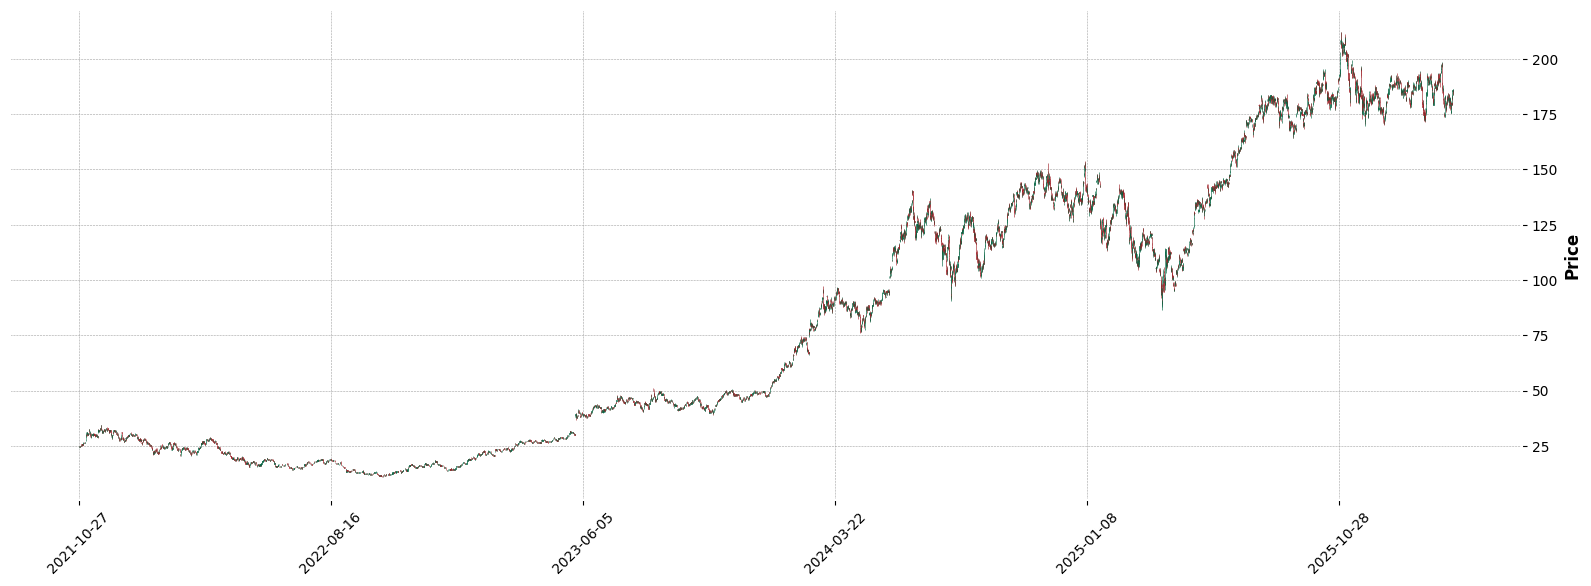

32 500 32 0
NVDA


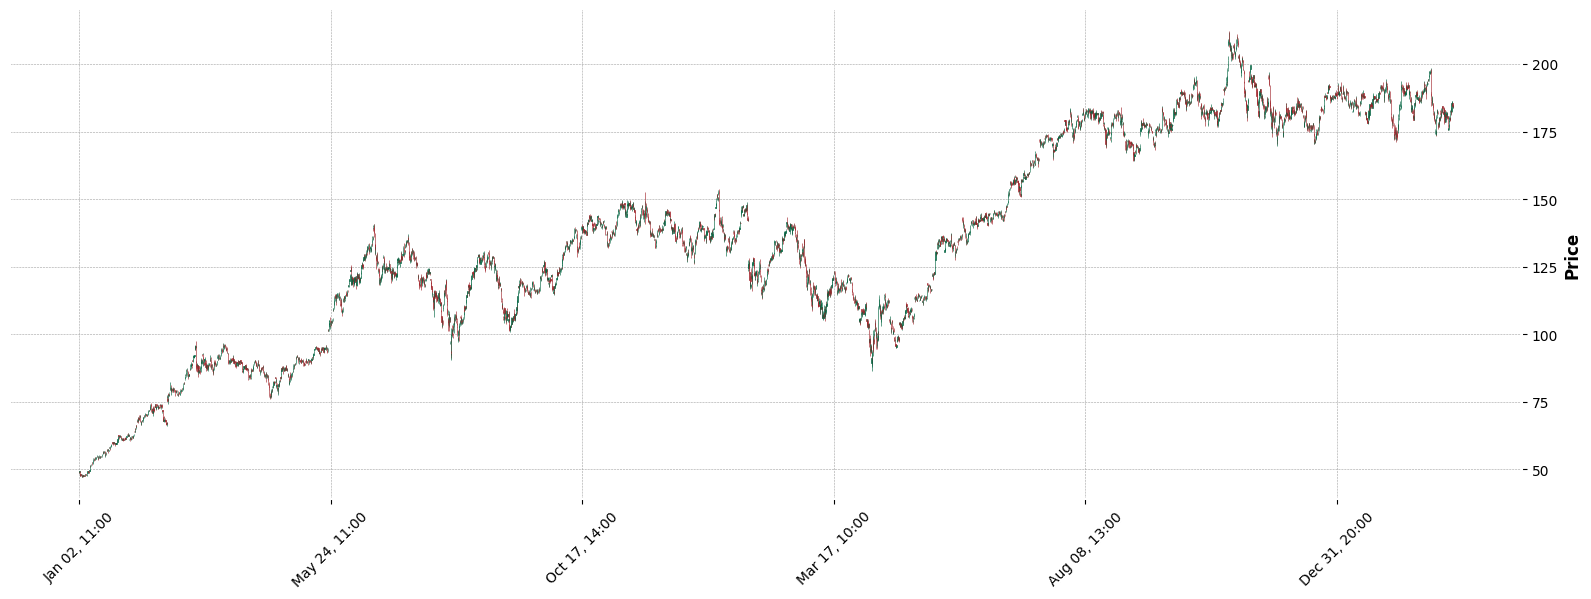

obtener_df_extremos


 83%|████████▎ | 4554/5462 [00:36<00:05, 170.70it/s]

In [ ]:
for valor in valores:
    print('Valor', valor)
    # N: Cantidad de "soportes" ocupados
    N = n_sizes[valor]
    sizes = (M, N)
    print(sizes)

    # 1. Leer el CSV
    df = pd.read_csv(f'{carpeta_data}{valor}.csv')
    df = df.sort_values(by='DateTime').reset_index(drop=True)

    # 2. Convertir la columna DateTime a datetime
    df['DateTime'] = pd.to_datetime(df['DateTime'])

    # 3. Establecer DateTime como índice
    df_plot = df.set_index('DateTime')

    if display_0:
        display('All gráfico', df)
        mpf.plot(df_plot, type = 'candle', volume = False, style = 'charles', figsize = (21, 7), datetime_format='%Y-%m-%d')

    df = df[df['DateTime'] >= '2024-01-01'].reset_index(drop=True) # Para no tomar un periodo tan antiguo
    ultimo_cierre = float(df['Close'].iloc[-1])
    ultimo_periodo = df['DateTime'].iloc[-1]
    dt_min = df['DateTime'].min()
    # Pendiente, cuando parámetros en nueva versión estén claros (ver este fragmento abajo en ANEXO 1)
    # df_parametros (una fila, con todos los parámetros actuales)
    # crear_fila_parametros(df_parametros, diccionario_parametros)


    df_plot_inicial = df.set_index('DateTime')

    dt_max = df['DateTime'].max()

    # Normalización de t, como referencia desde el inicio del periodo
    df['t'] = (df['DateTime'] - dt_min).dt.total_seconds() / 3600  # tiempo en horas desde el inicio
    df['t'] = df['t'] / df['t'].max()  # normalizar entre 0 y 1

    conjunto_N_preliminar = set()
    n_randoms_iniciales = 1000
    if f'{valor}_{N}_beta.pkl' in os.listdir('conjuntosN/'):
        conjunto_N_preliminar = pickle_act(f'conjuntosN/{valor}_{N}_beta')
        n_randoms_iniciales = 0
    
    #sys.exit(n_randoms_iniciales)

    print(N, M, len(conjunto_N_preliminar), n_randoms_iniciales)

    if display_1:
        print(valor)
        mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

    OCP = 0
    print('obtener_df_extremos')
    df_extremos, conjunto_N, conjunto_M = obtener_df_extremos(df, k, n, N, M, OCP, conjunto_N_preliminar, prints_general = True) # OCP es la cantidad de ordenes de compra planificadas (ya activadas en la plataforma) # Entrega conjunto_N y conjunto_M iniciales, dependiendo de los casos (puede que ya exista un conjunto_N precio, y se aprovecha para el algorítmo)
    print('buscar_soportes_optimos')
    conjunto_N, conjunto_M, df_extremos, df_FO = buscar_soportes_optimos_v4(valor, N, df_extremos, conjunto_N, conjunto_M, lambda_ponderador, n_randoms_iniciales = n_randoms_iniciales)  # Se obtiene la mejor combinación de soportes óptimos
    graficar_df_extremos(df_extremos, graficar = graficar_extremos) # Se grafican los pesos asociados a cada extremo

    # H_n son las distancias entre los soportes en conjunto_N
    L_n = list(conjunto_N)
    L_n.sort()
    H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]

    #display('df_extremos', df_extremos)
    print('Performance FO')
    graficar_performance_FO(df_FO, graficar = graficar_perf_FO) # Gráfico del comportamiento de FO
    graficar_soportes_all(df, conjunto_N, graficar = graficar_soportes) # Gráfico de soportes sobre el precio

    conjunto_N
    # Se guarda el conjunto actual
    pickle_act((f'conjuntosN/{valor}_{N}_beta'), conjunto_N, 'save')

Macroalgorítmo

In [ ]:
# Comenzar con t = T (60 días)

# Para cada t in range(T, len(df)):
#   0. definir el df entre t = 0 y t = t (A0)
#   # 1. Si t está en lista_cambios_soporte (cada d días, o d periodos) (t=T debe estar en la lista [ajuste inicial]) (A1)
#       # calcular soportes óptimos
#           # Este algorítmo tiene OA (Ordenes activas) y OCP (Ordenes de compra planificadas [están esperando que el precio las toque para activarse, ya están programadas como ordenes de compra en la plataforma])
#           # El objetivo es, con M puntos potenciales, llegar a que OCE + OCP = N soportes óptimos [OCE: Ordenes de compra en espera]
#           # 1.1 (Requiere algorítmo) Las ordenes de compra (precio = P) en espera, estarán sobre el precio actual y, se esperará a que el precio llegue a P+delta, para que se transforme en una OCP
    # De esta forma, la idea es ir buscando ordenes de compra y poder activarlas
    
    # 2. Cambio de SL
    #    Para cada OA de precio P
    #       Si p(t) [Precio en t], es mayor a P + delta1 y SL(OA) < P + delta2: (Primera configuración de SL que implique ganancia mínima) -> SL_new(OA) > Precio de compra
    #            SL(OA) = P + delta2 (delta1 > delta2)
    #       Si p(t) es mayor a SL(OA) + delta3: # Trailing stop, mover el stop loss hacia arriba
    #            SL(OA) = SL(OA) + delta4
    
    # 3. Evaluar valor en cuenta
    
    # 4. Evaluar cambios en los parámetros


## Estado de las ordenes de compra:
# OP: Orden potencial (pertenece al conjunto M inicial, donde solo algunas de ellas, se eligen como soportes óptimos)
# OCE: Ordenes de compra en espera (pertenecen al conjunto N de soportes óptimos, que están sobre el precio actual - delta. Cuando el precio actual supera a
#      P + delta, se transforman en OCP [P es el precio de la OCE]
# OCP: Ordenes de compra planificadas (ya están creadas en la plataforma, esperando que el precio las toque para activarse)
# OA: Ordenes abiertas (ya se ejecutaron y están abiertas)
# OC: Ordenes cerradas (se cerraron las ordenes abiertas)
#     Estás últimas se separan en 
#     OCL: Orden cerrada con loss
#     OCW: Orden cerrada con win

# Otros

In [ ]:
sys.exit('Otros')

SystemExit: Otros

In [ ]:
# Inicialización

dt_min = df['DateTime'].min()

dt_cut = dt_min + pd.Timedelta(days = T)
print(dt_min, dt_cut)

df_0 = df[(df['DateTime'] >= dt_min) & (df['DateTime'] < dt_cut)].copy() # df para comenzar las iteraciones (desde el inicio hasta T días después)
L_inicial = len(df_0)
print(len(df), len(df_0))
#sys.exit()

df_parametros = pd.DataFrame()
df_oc_all = pd.DataFrame()

for i_vela in tqdm.tqdm(range(len(df) + 1 - L_inicial), desc="Iteración en velas"):
    
    #print('i_vela', i_vela)
    
    if not activar:
        break
    
    # 0. Agregar una nueva vela al df y hacer lo siguiente
    df_0 = df.head(i_vela + L_inicial)
    
    ultimo_cierre = float(df_0['Close'].iloc[-1])
    ultimo_periodo = df_0['DateTime'].iloc[-1]
    
    # Pendiente Inicial...esto debe obtenerse de df_ordenes
    OCP = 0

    # Pendiente, cuando parámetros en nueva versión estén claros (ver este fragmento abajo en ANEXO 1)
    # df_parametros (una fila, con todos los parámetros actuales)
    # crear_fila_parametros(df_parametros, diccionario_parametros)
    
    df_plot_inicial = df_0.set_index('DateTime')

    dt_max = df['DateTime'].max()

    # Normalización de t, como referencia desde el inicio del periodo
    df_0['t'] = (df_0['DateTime'] - dt_min).dt.total_seconds() / 3600  # tiempo en horas desde el inicio
    df_0['t'] = df_0['t'] / df_0['t'].max()  # normalizar entre 0 y 1
    
    # 1: Recalcular soportes y REEMPLAZAR los que estaban (esto puede hacerse cada x velas, no en todas) [inicialmente, entra si o si i_vela == 0]
    if i_vela % paso == 0:

        print(f'\n\n\n\n PASO CADA {round(paso / 24)} DIAS {i_vela} \n\n\n\n')

        if display_1:
            display(f'df0 [gráfico i_vela] {i_vela}', df_0)
            mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

        if prints_generales:
            print('TO DO: Si quedan pocos soportes activos (no ejecutados)....menor a un umbral....entrar aquí también')
        
        df_extremos, conjunto_N, conjunto_M = obtener_df_extremos(df_0, k, n, N, M, OCP) # OCP es la cantidad de ordenes de compra planificadas (ya activadas en la plataforma) # Entrega conjunto_N y conjunto_M iniciales, dependiendo de los casos (puede que ya exista un conjunto_N precio, y se aprovecha para el algorítmo)
        conjunto_N, conjunto_M, df_extremos, df_FO = buscar_soportes_optimos(df_extremos, conjunto_N, conjunto_M, lambda_ponderador)  # Se obtiene la mejor combinación de soportes óptimos
        graficar_df_extremos(df_extremos, graficar = graficar_extremos) # Se grafican los pesos asociados a cada extremo
        
        # H_n son las distancias entre los soportes en conjunto_N
        L_n = list(conjunto_N)
        L_n.sort()
        H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]
        
        #display('df_extremos', df_extremos)
        print('Performance FO')
        graficar_performance_FO(df_FO, graficar = graficar_perf_FO) # Gráfico del comportamiento de FO
        graficar_soportes_all(df_0, conjunto_N, graficar = graficar_soportes) # Gráfico de soportes sobre el precio
        sys.exit('Continuar abajo con la revisión de la función generar_nuevas_oc (250111)')
        
        df_oc_all = generar_nuevas_oc(df_oc_all, conjunto_N, limite_low, limite_high, beta_low, beta_up, ultimo_cierre, delta_cambio_SL, delta_trigger, ultimo_periodo, delta_SL_LP)


In [ ]:
sys.exit('Otros de aqui hacia abajo en V2...seguir estudiando abajo y revisar funciones [260111]')

In [ ]:
# Inicialización

dt_min = df['DateTime'].min()

dt_cut = dt_min + pd.Timedelta(days = T)
print(dt_min, dt_cut)

df_0 = df[(df['DateTime'] >= dt_min) & (df['DateTime'] < dt_cut)].copy() # df para comenzar las iteraciones (desde el inicio hasta T días después)
L_inicial = len(df_0)
print(len(df), len(df_0))
#sys.exit()

df_parametros = pd.DataFrame()
df_oc_all = pd.DataFrame()

for i_vela in tqdm.tqdm(range(len(df) + 1 - L_inicial), desc="Iteración en velas"):
    
    #print('i_vela', i_vela)
    
    if not activar:
        break
    
    # 0. Agregar una nueva vela al df y hacer lo siguiente
    df_0 = df.head(i_vela + L_inicial)
    
    ultimo_cierre = float(df_0['Close'].iloc[-1])
    ultimo_periodo = df_0['DateTime'].iloc[-1]

    # ANEXO 1
    # -1. df-parametros (una fila, con todos los parámetros actuales)
    #crear_fila_parametros(df_parametros, diccionario_parametros)
    df_parametros_new = pd.DataFrame({'ultimo_cierre': [ultimo_cierre],
                                    'ultimo_periodo': [ultimo_periodo],
                                  'T': [T],
                                  'k': [k],
                                  'n': [n],
                                  'M': [M],
                                  'N': [N],
                                  'lambda_ponderador': [lambda_ponderador],
                                  'delta_trigger': [delta_trigger],
                                  'delta_cambio_SL': [delta_cambio_SL],
                                  'beta_low': [beta_low],
                                  'beta_up': [beta_up],
                                  'z_sl_lp': [z_sl_lp],
                                  'cuenta_size': [cuenta_size]})
    df_parametros = pd.concat([df_parametros, df_parametros_new], ignore_index=True) # Guardar al final de la iteración
    ## HASTA AQUI ANEXO 1
    
    df_plot_inicial = df_0.set_index('DateTime')

    dt_max = df['DateTime'].max()

    # Normalización de t, como referencia desde el inicio del periodo
    df_0['t'] = (df_0['DateTime'] - dt_min).dt.total_seconds() / 3600  # tiempo en horas desde el inicio
    df_0['t'] = df_0['t'] / df_0['t'].max()  # normalizar entre 0 y 1
    
    # 1: Recalcular soportes y REEMPLAZAR los que estaban (esto puede hacerse cada x velas, no en todas) [inicialmente, entra si o si i_vela == 0]
    if i_vela % paso == 0:

        print(f'\n\n\n\n PASO CADA {round(paso / 24)} DIAS {i_vela} \n\n\n\n')

        if display_1:
            display(f'df0 [gráfico i_vela] {i_vela}', df_0)
            mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

        if prints_generales:
            print('TO DO: Si quedan pocos soportes activos (no ejecutados)....menor a un umbral....entrar aquí también')

        df_extremos, conjunto_N, conjunto_M = obtener_df_extremos(df_0, k, n, N, M)
        conjunto_N, conjunto_M, df_extremos, df_FO = buscar_soportes_optimos(df_extremos, conjunto_N, conjunto_M, lambda_ponderador)
        graficar_df_extremos(df_extremos, graficar = graficar_extremos)
        
        # H_n son las distancias entre los soportes en conjunto_N
        L_n = list(conjunto_N)
        L_n.sort()
        H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]
        
        #display('df_extremos', df_extremos)
        
        graficar_performance_FO(df_FO, graficar = graficar_perf_FO)
        graficar_soportes_all(df_0, conjunto_N, graficar = graficar_soportes)

        if prints_generales:
            print('delta trigger y cambio SL', delta_trigger, delta_cambio_SL)

        # 1a. Crear ordenes de compra, bajo el precio inicial, en los soportes N (siempre)
        # 1b. Crear OC arriba del precio, siempre y cuando el precio máximo de la nueva vela, active el umbral
        mu, desv = float(df_extremos['Close'].mean()), float(df_extremos['Close'].std()) # mu y desv de los históricos hasta el momento [puede ser igual de los últimos k periodos]
        limite_low, limite_high = mu - 2 * desv, mu + 2 * desv
        limite_low, limite_high

        delta_SL_LP = z_sl_lp * desv  # Stop Loss a largo plazo (diferencia, bajo n [n - delta_SL_LP])
        if prints_generales:
            print('Actualización periódica de OC')
        df_oc_all = generar_nuevas_oc(df_oc_all, conjunto_N, limite_low, limite_high, beta_low, beta_up, ultimo_cierre, delta_cambio_SL, delta_trigger, ultimo_periodo, delta_SL_LP)
        
    
    #display(f'df_oc_all {i_vela}', df_oc_all)
    #display('df_0', df_0.tail(15))
    
    # ANCLA 2
    # Prev (para activar)
    #if i_vela != 0: # No se activa nada en la primera iteración, por defecto
    df_oc_activas = df_oc_all[df_oc_all['Status'] == 'Activa'].copy().reset_index()
    display('df_oc_activas', df_oc_activas)
    if len(df_oc_activas) > N:
        
        sys.exit(f'Existen más de {N} órdenes de compra activas.')
    

    ultimo_min, ultimo_max = float(df_0['Low'].iloc[-1]), float(df_0['High'].iloc[-1])
    #print('ultimo_min, ultimo_max', ultimo_min, ultimo_max)

    # Si se gatilla un trigger
    existen_oc = False
    
    for n_orden in range(len(df_oc_activas)):
        trigger = float(df_oc_activas.loc[n_orden, 'trigger'])
        if ultimo_min <= trigger <= ultimo_max: # Se ejecuta una orden
            #if not existen_oc:
            #    display('DETALLE df_oc_activas', df_oc_activas)
            existen_oc = True
            periodo = df_oc_activas.loc[n_orden, 'periodo']
            if prints_generales:
                print('Ejecución de orden', ultimo_min, trigger, ultimo_max)
            tipo_oc = df_oc_activas.loc[n_orden, 'tipo_oc']
            beta = float(df_oc_activas.loc[n_orden, 'beta'])
            cambio_SL = df_oc_activas.loc[n_orden, 'cambio_SL']
            sl_lp = float(df_oc_activas.loc[n_orden, 'SL_LP'])
            _id = int(df_oc_activas.loc[n_orden, 'id'])
            
            df_oc_all = ejecutar_orden_de_compra(df_oc_all, cuenta_size, beta, trigger, sl_lp, valor, _id, minimo_lotaje) # Ejecución de orden de compra
            
            if tipo_oc == 'S':
                # 3: Generar cambios de SL, si se gatilla una OC arriba
                # Actualizar el SL de las órdenes abiertas, si corresponde
                if prints_generales:
                    print('i vela', i_vela, ' Actualización stop loss por orden ejecutada arriba')
                graficar_soportes_all(df_0, conjunto_N, graficar_zoom = graficar_zoom)
                df_oc_all = actualizar_stop_loss_ordenes_abiertas(df_oc_all, cambio_SL, valor, continuar_por_ahora)
                # c251114
                
            #display('df_oc_all 0', df_oc_all)
            #graficar_soportes_all(df_0, conjunto_N, graficar = graficar_soportes)
    
    # Para cada orden de compra, reemplazar N    
    if existen_oc:
        #sys.exit('Continuar aqui 251222. Revisar')
        
        #display('df_oc_activas en existen_oc', df_oc_activas)
        conjunto_N = set(df_oc_activas['n']) # n activos aún (base)
        
        # TO DO: Todo esto es bien igual a lo que está arriba, agrupar en una función
        df_extremos, conjunto_N, conjunto_M = obtener_df_extremos(df_0, k, n, N, M, existe_solucion = True, conjunto_N = conjunto_N)
        conjunto_N, conjunto_M, df_extremos, df_FO = buscar_soportes_optimos(df_extremos, conjunto_N, conjunto_M, lambda_ponderador, sizes = sizes)
        graficar_df_extremos(df_extremos, graficar = graficar_extremos)
        
        # H_n son las distancias entre los soportes en conjunto_N
        L_n = list(conjunto_N)
        L_n.sort()
        H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]
        
        display('df_extremos', df_extremos)
        
        graficar_performance_FO(df_FO, graficar = graficar_perf_FO)
        graficar_soportes_all(df_0, conjunto_N, graficar = graficar_soportes)

        if prints_generales:
            print('delta trigger y cambio SL', delta_trigger, delta_cambio_SL)

        # 1a. Crear ordenes de compra, bajo el precio inicial, en los soportes N (siempre)
        # 1b. Crear OC arriba del precio, siempre y cuando el precio máximo de la nueva vela, active el umbral
        mu, desv = float(df_extremos['Close'].mean()), float(df_extremos['Close'].std()) # mu y desv de los históricos hasta el momento [puede ser igual de los últimos k periodos]
        limite_low, limite_high = mu - 2 * desv, mu + 2 * desv
        limite_low, limite_high

        delta_SL_LP = z_sl_lp * desv  # Stop Loss a largo plazo (diferencia, bajo n [n - delta_SL_LP])
        #print('Actualización reemplazo de OC', i_vela)
        #display('df_oc_all.head()', df_oc_all.head())
        df_oc_all = generar_nuevas_oc(df_oc_all, conjunto_N, limite_low, limite_high, beta_low, beta_up, ultimo_cierre, delta_cambio_SL, delta_trigger, ultimo_periodo, delta_SL_LP)
        
    if (i_vela % 100 == 0) and (i_vela != 0):
        if prints_generales:
            print('Continuar aquí 251028')
            print('Desarrollar actualizar valor de ordenes abiertas en df_oc_all y cuenta_size')
        if not continuar_por_ahora:
            sys.exit('Seguir desarrollo')
        # c251114
            #display('df_0', df_0)
            #display(mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7)))
            #sys.exit('Continuar abajo en [ANCLA 2]')
        
    
    #sys.exit('Revisión para continuar abajo')
    # 2: Evaluar si se ejecuta una OC abajo (toque de soporte) y/o una OC arriba (alcanza el trigger [gatillante]) > Ejecutarla y guardarla en una BD
    #     Incluir en la BD el $ en cuenta, para calcular posteriormente pérdida o ganancia
    

    

In [ ]:
df_0

In [ ]:
df_oc_all

In [ ]:
# muestrame los triggers duplicados
df_oc_all[df_oc_all.duplicated(subset=['trigger'], keep=False)].sort_values(by='trigger')

# Algorítmo Preliminar (Inicial)

In [ ]:
sys.exit('Otros de aquí hhacia abajo')

In [ ]:
# 1. Leer el CSV
df = pd.read_csv(f'{carpeta_data}{valor}.csv')

# 2. Convertir la columna DateTime a datetime
df['DateTime'] = pd.to_datetime(df['DateTime'])

# 3. Establecer DateTime como índice
df_plot = df.set_index('DateTime')

display(df.head())

mpf.plot(df_plot, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))



In [ ]:
# Parámetros

# T: Cantidad de días previos para selección de la ventana
T = 60 # 60 días
# k: ponderador para mínimos de los días futuros: P = delta pasado + k * delta futuro
k = 1
# n: exp de ponderación por tiempo: Ponderación por tiempo: w_i = exp(-n*(T-i)), i = 1,...,T / o puede ser w_i = A * t^n 
n = 0
# M: Cantidad de "soportes tentativos" fuera de los ocupados
M = 500
# N: Cantidad de "soportes" ocupados
N = 10
# lambda: ponderador para FO: Calidad resistencias - lambda * desv(h) / prom(h) ...h es la separación entre resistencias h_i = r_i - r_(i-1), para todo i = 2,...,N
lambda_ponderador = 0.01
# delta trigger (en %), sobre el cambio SL
delta_trigger = 0.5
# delta cambio stop loss (en %)
delta_cambio_SL = 0.5

# Recordar que el orden, de arriba hacia abajo es delta trigger / delta cambio SL / soporte

In [ ]:
dt_min = df['DateTime'].min()
dt_min

dt_cut = dt_min + pd.Timedelta(days = T)
dt_cut

df_inicial = df[(df['DateTime'] >= dt_min) & (df['DateTime'] < dt_cut)].copy()
df_plot_inicial = df_inicial.set_index('DateTime')
mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

dt_max = df['DateTime'].max()

# Normalización de t, como referencia desde el inicio del periodo
df_inicial['t'] = (df_inicial['DateTime'] - dt_min).dt.total_seconds() / 3600  # tiempo en horas desde el inicio
df_inicial['t'] = df_inicial['t'] / df_inicial['t'].max()  # normalizar entre 0 y 1
df_inicial


In [ ]:
import numpy as np
def calcular_distancias(df, find_low=True, find_high=True):
    n = len(df)
    df = df.copy()
    
    if find_low:
        df["Low_left"] = np.nan
        df["Low_right"] = np.nan
    if find_high:
        df["High_left"] = np.nan
        df["High_right"] = np.nan

    max_t = df["t"].max()

    for i in range(n):
        low_val = df.loc[i, "Low"]
        high_val = df.loc[i, "High"]
        t_i = df.loc[i, "t"]
        
        if find_low:
            # Buscar hacia la izquierda (Low)
            for j in range(i-1, -1, -1):
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_left"] = t_i - df.loc[j, "t"]
                    break

            # Buscar hacia la derecha (Low)
            for j in range(i+1, n):
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_right"] = df.loc[j, "t"] - t_i
                    break

        if find_high:
            # Buscar hacia la izquierda (High)
            for j in range(i-1, -1, -1):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_left"] = t_i - df.loc[j, "t"]
                    break

            # Buscar hacia la derecha (High)
            for j in range(i+1, n):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_right"] = df.loc[j, "t"] - t_i
                    break

    # Rellenar los NaN con t o max(t) - t
    if find_low:
        df["Low_left"] = df["Low_left"].fillna(df["t"])
        df["Low_right"] = df["Low_right"].fillna(max_t - df["t"])
    if find_high:
        df["High_left"] = df["High_left"].fillna(df["t"])
        df["High_right"] = df["High_right"].fillna(max_t - df["t"])

    return df

df_extremos = calcular_distancias(df_inicial, find_high=False)
df_extremos

In [ ]:
# Poonderadores (audios wsp personal 251002)
df_extremos['y'] = df_extremos['Low_left'] + k * df_extremos['Low_right']
df_extremos['w'] = df_extremos['t'] ** n

In [ ]:
df_extremos

# Grafica en una matriz de 2x1, Low e y
plt.figure(figsize=(21, 10))
plt.subplot(2, 1, 1)
plt.plot(df_extremos['DateTime'], df_extremos['Low'], linestyle='-', color='b', label='Low')
plt.plot(df_extremos['DateTime'], df_extremos['High'], linestyle='-', color='g', label='High')
plt.xlabel('DateTime')
plt.ylabel('Low')
plt.title('Gráfico de Low en función de DateTime')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(df_extremos['DateTime'], df_extremos['y'], linestyle='-', color='r', label='y (distancia ponderada)')
plt.xlabel('DateTime')
plt.ylabel('y (distancia ponderada)')
plt.title('Gráfico de y en función de DateTime')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


Búsqueda de Soportes

In [ ]:
N, M

In [ ]:
df_extremos

p_min, p_max = df_extremos['Low'].min(), df_extremos['Low'].max()
p_min, p_max

In [ ]:
existe_solucion = False
if existe_solucion:
    sys.exit('Desarrollar')

# Si no existe solución, generar todas las posibles
all_soluciones_posibles = np.linspace(p_min, p_max, M + N).tolist()
print(len(all_soluciones_posibles))

# Elegir N random de este conjunto (deben ser distintas)

conjunto_N = set(random.sample(all_soluciones_posibles, N))
conjunto_M = set(all_soluciones_posibles) - conjunto_N
len(conjunto_N), len(conjunto_M)


In [ ]:
# Al Low en df extremos, asignarle el soporte más cercano en conjunto_N
# Revisadas en nueva versión
def asignar_soporte(df, soportes):
    # Devuelve la distancia entre el Low y el soporte más cercano
    df = df.copy()
    df['Dist_Soporte'] = df['Low'].apply(lambda x: min(soportes, key=lambda s: abs(s - x)))
    return df

def calcular_FO(df_extremos, conjunto_N, lambda_ponderador):

    biobjetivo = True
    
    df_extremos = asignar_soporte(df_extremos, conjunto_N) # Se asigna el soporte más cercano
    df_extremos['dist'] = df_extremos['Dist_Soporte'] ** 2 # Se Penalizan distancias miuy grandes
    dist_max = df_extremos['dist'].max()
    df_extremos['h_dist'] = 1 - df_extremos['dist'] / dist_max # Normaliza, buscando que las distancias más pequeñas tengan mayor H_dist
    df_extremos
    
    # Calcular la función objetivo

    df_extremos['z'] = df_extremos['y'] * df_extremos['w'] * df_extremos['h_dist'] # Multiplicación de los tres términos
    # z debe ser grande
    # y: mejor representación de soporte (más aislado)
    # w: mas cercano (premia a las velas más recientes)
    # h_dist: mejor ajuste al soporte del conjunto n (más cercano al n asignado)

    L_n = list(conjunto_N)
    L_n.sort()
    H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))] # Distancias entre los soportes del conjunto_N

    # calcula promedio de conjunto H_n
    promedio_conjunto_H = np.mean(H_n)
    # desviación estándar de conjunto H_n
    desviacion_conjunto_H = np.std(H_n)

    # cv del conjunto H_n
    cv_conjunto_H = desviacion_conjunto_H / promedio_conjunto_H

    # cv_conjunto_N debe ser pequeño
    
    if biobjetivo:
        #print("df_extremos['z'].sum() / len(df_extremos)", df_extremos['z'].sum() / len(df_extremos), df_extremos['z'].sum(), len(df_extremos))
        #print('cv_conjunto_H', cv_conjunto_H, desviacion_conjunto_H, promedio_conjunto_H)
        # FO = sum(z) - lambda * cv_conjunto_N
        #sys.exit('También normalizar cv conjunto H y definir un nuevo lambda_ponderador inicial')
        FO = df_extremos['z'].sum() / len(df_extremos) - lambda_ponderador * cv_conjunto_H # Se divide por len para normalizar
    else:
        FO = (df_extremos['z'].sum() / len(df_extremos)) / cv_conjunto_H
        
    FO = float(FO)
    return FO, df_extremos

In [ ]:
"""
df_extremos['h_dist'].min(), df_extremos['h_dist'].max()

# Grafica un hist de h_dist
plt.figure(figsize=(10, 6))
plt.hist(df_extremos['h_dist'], bins=30, color='salmon', alpha=0.5)
plt.xlabel('h_dist')
plt.ylabel('Frecuencia')
plt.title('Histograma de h_dist')
plt.grid()
plt.show()
"""

In [ ]:
len(conjunto_N) * len(conjunto_M)

In [ ]:
# Uno a uno, reemplaza un punto del conjunto N por uno del conjunto M

print('L(N) * L(M)', len(conjunto_N) * len(conjunto_M))
df_FO = pd.DataFrame(columns = ['Iteracion', 'FO'])

# inicialización
FO, df_extremos = calcular_FO(df_extremos, conjunto_N, lambda_ponderador)
i = 0
while True:
    cambios = False
    #print('i', i)
    j = 0
    for n, m in tqdm.tqdm(itertools.product(conjunto_N, conjunto_M)):
        j += 1
        #print(n, m)
        
        conjunto_N_iter = conjunto_N.copy()
        conjunto_N_iter.remove(n)
        conjunto_N_iter.add(m)
        
        conjunto_M_iter = conjunto_M.copy()
        conjunto_M_iter.remove(m)
        conjunto_M_iter.add(n)

        FO_iter, df_extremos_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador)
        
        if FO_iter > FO:
            #print(f'Nueva FO: {round(FO_iter, 1)} > {round(FO, 1)}, con n={round(n, 0)} por m={round(m, 0)}')
            #print(f'Mejora de {round(FO_iter - FO, 2)}')
            FO = FO_iter
            df_extremos = df_extremos_iter
            conjunto_N = conjunto_N_iter
            conjunto_M = conjunto_M_iter
            cambios = True
            break
            
    df_FO_new = pd.DataFrame({'Iteracion': [i], 'FO': [FO], 'n_iters': [j]})
    df_FO = pd.concat([df_FO, df_FO_new], ignore_index=True)
    i += 1
    if not cambios:
        break


In [ ]:
conjunto_N

L_n = list(conjunto_N)
L_n.sort()
H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]
H_n

In [ ]:
df_extremos

In [ ]:
# Graficar df_FO a doble eje (FO y n_iters vs iteracion)

plt.figure(figsize = (21, 7))
plt.plot(df_FO['Iteracion'], df_FO['FO'], linestyle='-', color='b', label='FO')
plt.ylabel('FO')
plt.xlabel('Iteración')
plt.twinx()
plt.plot(df_FO['Iteracion'], df_FO['n_iters'], linestyle='-', color='r', label='n_iters')
plt.ylabel('n_iters')
plt.title('Evolución de la Función Objetivo (FO) y n_iters por Iteración')
plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (21, 7))
plt.plot(df_extremos['DateTime'], df_extremos['Low'], linestyle='-', color='b', label='Low')
plt.plot(df_extremos['DateTime'], df_extremos['High'], linestyle='-', color='g', label='High')
for n in list(conjunto_N):
    plt.axhline(y = n, color = 'r', linestyle = '--', alpha = 0.5)
plt.xlabel('DateTime')
plt.ylabel('Low')
plt.title('Gráfico de Low en función de DateTime')
plt.grid() # Agrega una cuadrícula
plt.legend()
plt.show()

In [ ]:
# Que viene después?

# 1. Crear ordenes de compra, bajo el precio inicial, en los soportes N
# 1A. Crear OC arriba del precio, siempe y cuando el precio máximo de la nueva vela, active el umbral
# B. Agregar una nueva vela al df y hacer lo siguiente
# B1: Evaluar si se ejecuta una OC abajo (toque de soporte) y/o una OC arriba (alcanza el trigger [gatillante]) > Ejecutarla y guardarla en una BD
#     Incluir en la BD el $ en cuenta, para calcular posteriormente pérdida o ganancia
# B2: Generar cambios de SL, si se gatilla una OC arriba
# B3: Evaluar si hay cierres de operación y cerrar en caso de que existan
# B4: Recalcular soportes y REEMPLAZAR los que estaban (esto puede hacerse cada x velas, no en todas) 
# B5: Con RLM, y gradient descent (70% train - 30% test), optimizar los parámetros declarados arriba

# ** En todos los casos, ir guardando los registros
delta_trigger, delta_cambio_SL

In [ ]:
sys.exit('Continuar aquí 251007')

# Otros

In [ ]:
import yfinance as yf
print(yf.__version__)

# Definir ticker y periodo
ticker = 'USDCLP=X'  # ejemplo Apple
#ticker = 'AAPL'  # ejemplo Apple
print(ticker)
data = yf.download(ticker)  # intervalo de 60 minutos
data


In [ ]:

from datetime import datetime, timedelta
import yfinance as yf

end_date = datetime.today()
start_date = end_date - timedelta(days=30)

data = yf.download('USDCLP=X', start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')
print(data.head())


In [ ]:

import yfinance as yf
from datetime import datetime, timedelta

ticker = yf.Ticker("USDCLP=X")
end_date = datetime.today()
start_date = end_date - timedelta(days=10)

data = ticker.history(start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')



# Original chat gpt

https://chatgpt.com/share/686720eb-f8f4-8009-a56b-5d97bced1a2e

In [ ]:
# ----------------------------------------
# 1. Instalar librerías (si no las tienes)
# ----------------------------------------
# pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# 2. Descargar datos históricos
# ----------------------------------------
# Por ejemplo, de Apple
ticker = "AAPL"
df = yf.download(ticker, start="2018-01-01", end="2023-01-01")
df = df[['Close']].copy()

# ----------------------------------------
# 3. Calcular medias móviles
# ----------------------------------------
df['SMA50'] = df['Close'].rolling(window=50).mean()
df['SMA200'] = df['Close'].rolling(window=200).mean()

# ----------------------------------------
# 4. Generar señales de compra/venta
# ----------------------------------------
df['Signal'] = 0
df.loc[df['SMA50'] > df['SMA200'], 'Signal'] = 1
df.loc[df['SMA50'] <= df['SMA200'], 'Signal'] = 0
df['Position'] = df['Signal'].diff()

# ----------------------------------------
# 5. Graficar
# ----------------------------------------
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Precio de Cierre', alpha=0.5)
plt.plot(df['SMA50'], label='SMA 50', alpha=0.9)
plt.plot(df['SMA200'], label='SMA 200', alpha=0.9)
plt.plot(df[df['Position'] == 1].index, 
         df['SMA50'][df['Position'] == 1],
         '^', markersize=12, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, 
         df['SMA50'][df['Position'] == -1],
         'v', markersize=12, color='r', label='Sell Signal')
plt.title(f"{ticker} - Estrategia Cruce de Medias Móviles")
plt.legend()
plt.show()

# ----------------------------------------
# 6. Backtest muy básico
# ----------------------------------------
# Retornos diarios
df['Return'] = df['Close'].pct_change()

# Retornos de estrategia
df['Strategy'] = df['Signal'].shift(1) * df['Return']

df[['Return', 'Strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(12,6))
plt.title(f"{ticker} - Buy & Hold vs Estrategia")
plt.show()


In [ ]:
sys.exit()

# Otras pruebas

In [ ]:
# ----------------------------------------
# 1. Instalar librerías (si no las tienes)
# ----------------------------------------
# pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# 2. Descargar datos históricos
# ----------------------------------------
# Por ejemplo, de Apple
ticker = "MSFT"
df = yf.download(ticker, start="2020-01-01")
df = df[['Close']].copy()

# ----------------------------------------
# 3. Calcular medias móviles
# ----------------------------------------
df['SMA50'] = df['Close'].rolling(window=10).mean()
df['SMA200'] = df['Close'].rolling(window=40).mean()

# ----------------------------------------
# 4. Generar señales de compra/venta
# ----------------------------------------
df['Signal'] = 0
df.loc[df['SMA50'] > df['SMA200'], 'Signal'] = 1
df.loc[df['SMA50'] <= df['SMA200'], 'Signal'] = 0
df['Position'] = df['Signal'].diff()

# ----------------------------------------
# 5. Graficar
# ----------------------------------------
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Precio de Cierre', alpha=0.5)
plt.plot(df['SMA50'], label='SMA 50', alpha=0.9)
plt.plot(df['SMA200'], label='SMA 200', alpha=0.9)
plt.plot(df[df['Position'] == 1].index, 
         df['SMA50'][df['Position'] == 1],
         '^', markersize=12, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, 
         df['SMA50'][df['Position'] == -1],
         'v', markersize=12, color='r', label='Sell Signal')
plt.title(f"{ticker} - Estrategia Cruce de Medias Móviles")
plt.legend()
plt.show()

# Encuentra el primer día donde la estrategia toma posición (Signal == 1)
start_idx = df[df['Signal'] == 1].first_valid_index()

# Corta el DataFrame desde ese momento
df_bt = df.loc[start_idx:].copy()

# Calcula retornos de ambas estrategias desde el mismo punto
df_bt['Return'] = df_bt['Close'].pct_change()
df_bt['Strategy'] = df_bt['Signal'].shift(1) * df_bt['Return']

# Capital acumulado
df_bt['Equity_BuyHold'] = (1 + df_bt['Return']).cumprod()
df_bt['Equity_Strategy'] = (1 + df_bt['Strategy']).cumprod()

# Graficar
df_bt[['Equity_BuyHold', 'Equity_Strategy']].plot(figsize=(12,6))
plt.title(f"{ticker} - Buy & Hold vs Estrategia (Sincronizados)")
plt.show()


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# ------------------------------
# 1. Descargar datos
# ------------------------------
ticker = "MSFT"
start_date = "2018-01-01"
df = yf.download(ticker, start=start_date)
df = df[['Close']].copy()

# ------------------------------
# 2. Definir rangos para las medias móviles
# ------------------------------
#cortas = range(5, 30, 5)
#medias = range(30, 90, 10)
#largas = range(90, 210, 10)

cortas = range(5, 30, 15)
medias = range(30, 90, 30)
largas = range(90, 210, 30)


#
# Función estrategia
def run_strategy(df_base, s_corta, s_media, s_larga):
    df = df_base.copy()

    # Asegurar que 'Return' exista (calcular si no está)
    if 'Return' not in df.columns:
        df['Return'] = df['Close'].pct_change()

    df['SMA_c'] = df['Close'].rolling(window=s_corta).mean()
    df['SMA_m'] = df['Close'].rolling(window=s_media).mean()
    df['SMA_l'] = df['Close'].rolling(window=s_larga).mean()

    def classify(row):
        try:
            s1, s2, s3 = float(row['SMA_c']), float(row['SMA_m']), float(row['SMA_l'])
        except:
            return np.nan
        smas = [('c', s1), ('m', s2), ('l', s3)]
        ranking = ''.join([k for k, _ in sorted(smas, key=lambda x: -x[1])])
        if ranking == 'cml':
            return 1
        elif ranking == 'mcl':
            return 0.5
        elif ranking in ['mlc', 'clm']:
            return 0.25
        elif ranking in ['lmc', 'lcm']:
            return 0
        return 0

    df['Signal'] = df.apply(classify, axis=1)
    df.dropna(inplace=True)
    df['Position'] = df['Signal'].shift(1)
    df['Strategy'] = df['Position'] * df['Return']

    first_entry_idx = df.index[(df['Position'] > 0)].min()
    if pd.isna(first_entry_idx):
        # Nunca entra, retorno 1 (sin ganancias)
        return 1.0, 1.0, df

    df_sub = df.loc[first_entry_idx:].copy()
    df_sub['Equity_Strategy'] = (1 + df_sub['Strategy']).cumprod()
    df_sub['Equity_BuyHold'] = (1 + df_sub['Return']).cumprod()

    return df_sub['Equity_Strategy'].iloc[-1], df_sub['Equity_BuyHold'].iloc[-1], df_sub


# Ejecutar grid
results = []
combos = [ (s_c, s_m, s_l) for s_c, s_m, s_l in product(cortas, medias, largas) if s_c < s_m < s_l ]

for s_c, s_m, s_l in tqdm(combos, desc="Probando combinaciones"):
    try:
        strat_final, bh_final, _ = run_strategy(df, s_c, s_m, s_l)
        
        # Debug print para verificar valores
        print(f"Combo ({s_c},{s_m},{s_l}) -> strat_final: {strat_final}, bh_final: {bh_final}")
        
        # Validar que sean floats y no nan
        if (isinstance(strat_final, float) and isinstance(bh_final, float) 
            and not np.isnan(strat_final) and not np.isnan(bh_final)):
            results.append({
                'Corta': s_c, 'Media': s_m, 'Larga': s_l, 
                'EquityStrategy': strat_final, 'EquityBuyHold': bh_final
            })
        else:
            print(f"Valores inválidos para combo ({s_c},{s_m},{s_l}), se omite.")
            
    except Exception as e:
        print(f"Error combo ({s_c},{s_m},{s_l}): {e}")

results_df = pd.DataFrame(results)

print("Columnas del DataFrame:", results_df.columns)
print("Primeras filas del DataFrame:")
print(results_df.head())

# Ordenar solo si la columna existe
if 'EquityStrategy' in results_df.columns:
    results_df.sort_values('EquityStrategy', ascending=False, inplace=True)
else:
    print("No se encontró la columna 'EquityStrategy' en results_df. No se ordenará.")


# Ver columnas y primeras filas (debug)
print(results_df.columns)
print(results_df.head())

# Ordenar por EquityStrategy
results_df.sort_values('EquityStrategy', ascending=False, inplace=True)

print("Top 10 mejores combinaciones:")
print(results_df.head(10))

# Graficar las 10 mejores combinaciones
plt.figure(figsize=(16, 12))

top_10 = results_df.head(10).reset_index(drop=True)

for i, row in top_10.iterrows():
    s_c, s_m, s_l = int(row['Corta']), int(row['Media']), int(row['Larga'])
    print(f"Graficando combinación: Corta={s_c} Media={s_m} Larga={s_l}")
    _, _, df_plot = run_strategy(df, s_c, s_m, s_l)

    plt.subplot(5, 2, i+1)
    plt.plot(df_plot.index, df_plot['Equity_BuyHold'], label='Buy & Hold', linestyle='--')
    plt.plot(df_plot.index, df_plot['Equity_Strategy'], label=f'SMA({s_c},{s_m},{s_l})')
    plt.title(f"{ticker} - SMA({s_c}, {s_m}, {s_l})\nEquity Estrategia: {results_df.loc[i,'EquityStrategy']:.2f}")
    plt.ylabel('Multiplicador capital')
    plt.xlabel('Fecha')
    plt.legend(fontsize=8)
    plt.grid(True)


plt.tight_layout()
plt.show()

# Fundamentales

In [ ]:
import yfinance as yf
ticker = yf.Ticker("MSFT")
info = ticker.info


In [ ]:
info

In [ ]:
import yfinance as yf
import pandas as pd

# Lista de símbolos (puedes agregar los que quieras)
symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

# Campos fundamentales que queremos extraer
fundamental_fields = {
    "shortName": "Nombre",
    "sector": "Sector",
    "marketCap": "MarketCap",
    "trailingPE": "PE",
    "forwardPE": "ForwardPE",
    "returnOnEquity": "ROE",
    "profitMargins": "MargenNeto",
    "dividendYield": "DivYield",
    "beta": "Beta"
}

# Crear lista para resultados
data = []

for symbol in symbols:
    try:
        ticker = yf.Ticker(symbol)
        info = ticker.info

        row = {"Ticker": symbol}
        for key, label in fundamental_fields.items():
            row[label] = info.get(key, None)

        data.append(row)

    except Exception as e:
        print(f"Error con {symbol}: {e}")

# Crear DataFrame
df_fundamentales = pd.DataFrame(data)

# Mostrar
display(df_fundamentales)

# Evitar división por cero o NaN en PE o DivYield:
df_fundamentales['PE'].replace(0, np.nan, inplace=True)
df_fundamentales['DivYield'].fillna(0, inplace=True)

# Normalizamos cada indicador para que estén en rango similar (0 a 1)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df_fundamentales['score_ROE'] = normalize(df_fundamentales['ROE'])
df_fundamentales['score_PE'] = 1 - normalize(df_fundamentales['PE'])  # Inverso porque PE bajo es bueno
df_fundamentales['score_DivYield'] = normalize(df_fundamentales['DivYield'])

# Score total simple (promedio)
df_fundamentales['Score_Total'] = df_fundamentales[['score_ROE', 'score_PE', 'score_DivYield']].mean(axis=1)

# Ordenar por score descendente
df_sorted = df_fundamentales.sort_values('Score_Total', ascending=False)

# Mostrar top 5
display(df_sorted[['Ticker', 'Nombre', 'Score_Total', 'ROE', 'PE', 'DivYield']].head(5))

In [ ]:
import pandas as pd
import yfinance as yf
from IPython.display import display

# Obtener la tabla con los componentes del S&P 500 desde Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
tables = pd.read_html(url)
df_sp500 = tables[0]
df_sp500

In [ ]:
import pandas as pd
import yfinance as yf
from IPython.display import display

# Obtener la tabla con los componentes del S&P 500 desde Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
tables = pd.read_html(url)
df_sp500 = tables[0]

# Extraer símbolos (Tickers)
tickers = df_sp500['Symbol'].tolist()[:50]

print(f"Número de empresas obtenidas: {len(tickers)}")

# Por ejemplo, tomar las primeras 100 para no saturar la consulta
tickers = tickers[:10]

# Función para obtener fundamentales (como antes)
def get_fundamentals(sym):
    try:
        ticker = yf.Ticker(sym)
        info = ticker.info
        data = {
            'Ticker': sym,
            'Nombre': info.get('shortName', None),
            'Sector': info.get('sector', None),
            'MarketCap': info.get('marketCap', None),
            'PE': info.get('trailingPE', None),
            'ForwardPE': info.get('forwardPE', None),
            'ROE': info.get('returnOnEquity', None),
            'NetMargin': info.get('profitMargins', None),
            'DivYield': info.get('dividendYield', None),
            'Beta': info.get('beta', None),
            'Price': info.get('currentPrice', None)
        }
        return data
    except Exception as e:
        print(f"Error con {sym}: {e}")
        return None

# Obtener fundamentales para las 100 empresas (puede tardar un poco)
fundamentals = []
for sym in tickers:
    f = get_fundamentals(sym)
    if f:
        fundamentals.append(f)

df = pd.DataFrame(fundamentals)
display(df.head(20))


# Ejemplo sencillo de score:
# Sumamos puntajes (por ejemplo: ROE positivo suma, PE bajo suma, D/E bajo suma, etc.)
def score_row(r):
    score = 0
    if pd.notna(r['ROE']):
        score += (2 * r['ROE'])
    if pd.notna(r['PE']) and r['PE'] < 25:
        score += 1
    if pd.notna(r['NetMargin']):
        score += (0.5 * r['NetMargin'])
    if pd.notna(r['DivYield']) and r['DivYield'] > 0.01:
        score += 0.5
    return score


df['Score'] = df.apply(score_row, axis=1)

# Ordenar por Score descendente
df = df.sort_values('Score', ascending=False)

print("\nTop activos según score fundamental:")
display(df[['Ticker', 'Nombre', 'Score']])


In [ ]:
ticker = yf.Ticker('BTC-USD')
info = ticker.info
info

In [ ]:
print(df.columns)

In [ ]:
sys.exit()

In [ ]:
# ----------------------------------------
# 1. Instalar librerías (si no las tienes)
# ----------------------------------------
# pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# 2. Descargar datos históricos
# ----------------------------------------
# Por ejemplo, de Apple
ticker = "TSLA"
df = yf.download(ticker)
df = df[['Close']].copy()

# ----------------------------------------
# 3. Calcular medias móviles
# ----------------------------------------
df['SMA50'] = df['Close'].rolling(window=20).mean()
df['SMA200'] = df['Close'].rolling(window=50).mean()

# ----------------------------------------
# 4. Generar señales de compra/venta
# ----------------------------------------
df['Signal'] = 0
df.loc[df['SMA50'] > df['SMA200'], 'Signal'] = 1
df.loc[df['SMA50'] <= df['SMA200'], 'Signal'] = 0
df['Position'] = df['Signal'].diff()

# ----------------------------------------
# 5. Graficar
# ----------------------------------------
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Precio de Cierre', alpha=0.5)
plt.plot(df['SMA50'], label='SMA 50', alpha=0.9)
plt.plot(df['SMA200'], label='SMA 200', alpha=0.9)
plt.plot(df[df['Position'] == 1].index, 
         df['SMA50'][df['Position'] == 1],
         '^', markersize=12, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, 
         df['SMA50'][df['Position'] == -1],
         'v', markersize=12, color='r', label='Sell Signal')
plt.title(f"{ticker} - Estrategia Cruce de Medias Móviles")
plt.legend()
plt.show()

# ----------------------------------------
# 6. Backtest muy básico
# ----------------------------------------
# Retornos diarios
df['Return'] = df['Close'].pct_change()

# Retornos de estrategia
df['Strategy'] = df['Signal'].shift(1) * df['Return']

df[['Return', 'Strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(12,6))
plt.title(f"{ticker} - Buy & Hold vs Estrategia")
plt.show()


In [ ]:
import backtrader as bt
from datetime import datetime


class SmaCross(bt.Strategy):
    # Estrategia de cruce de medias móviles
    def __init__(self):
        sma1 = bt.indicators.SimpleMovingAverage(self.data.close, period=50)
        sma2 = bt.indicators.SimpleMovingAverage(self.data.close, period=200)
        self.crossover = bt.indicators.CrossOver(sma1, sma2)

    def next(self):
        if not self.position:
            if self.crossover > 0:
                self.buy()
        elif self.crossover < 0:
            self.sell()

cerebro = bt.Cerebro()
data = bt.feeds.YahooFinanceData(dataname='AAPL',
                                 fromdate=datetime(2018, 1, 1),
                                 todate=datetime(2023, 1, 1))
cerebro.adddata(data)
cerebro.addstrategy(SmaCross)
cerebro.run()
cerebro.plot()
